0. <a id="input_0"></a><span style="background-color:#FEDA8B;">
Remember to add your declaration of collaborations, AI use and external resources.
</span>

# Basics of clustering on the *Dry Bean* dataset

## Preamble

### Importing libraries

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/


From the *scikit-learn* library (https://scikit-learn.org/stable/api/index.html), we need the implementations of the clustering algorithms (`sklearn.cluster`), data preprocessing such as scaling (`sklearn.preprocessing`) and evaluation metrics (`sklearn.metrics`).

The first three lines below are Python 'magic commands', respectively to display plots inline in the notebook, to install the seaborn library and to display plots as scalable vector graphics (svg). Depending on goals and on the configuration of the IPython kernel used, different magic commands might need to be uncommented.
The last three lines are to customize the style of figures, especially adding a light gray grid and increasing the default figure width.

In [1]:
# %matplotlib inline
# %pip install seaborn
# %config InlineBackend.figure_formats = ["svg"]

import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

from sklearn import cluster, preprocessing, metrics

seaborn.set_theme(style="white",
                  rc={"axes.grid": True, "grid.color": '#eaeaf2', "xtick.bottom": True, "ytick.left": True,
                     "figure.figsize": (10, 5)})

### Repeatability

We initialize a `RandomState` instance with a fixed seed and store it as variable `RS`, to be passed as value for the `random_state` parameter to all *scikit-learn* objects that use randomness.
This makes the analysis in this notebook repeatable. That is, it ensures that every time we restart the kernel and run all cells from top to bottom we obtain the same results, so that we can meaningfully discuss them.

If we run cells repeatedly or in a different order, since the sequence of calls to the random number generator will be different, we might obtain different results.
In order to explore the behavior of the methods, for example during development, we set variable `RS` to `None`, so that the global `RandomState` instance from `numpy` will be used.

For details about controlling randomness when using *scikit-learn*, see https://scikit-learn.org/stable/common_pitfalls.html#controlling-randomness.

1. <a id="input_1"></a><span style="background-color:#FEDA8B;">
Set the value of `SEED` in the first line below to your student number.
</span>

In [2]:
# ✏️
SEED = 1
RS = numpy.random.RandomState(SEED)
# RS = None

### Data source

The [*Dry Bean* dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) is the main example dataset used in part II of the course.

The classification task typically considered with this dataset is to predict the variety of a dry bean specimen based on measurements automatically derived from a digital image taken of it following a standardized protocol using a high-resolution camera.

The original dataset contains sixteen descriptive attributes recording physical measurements and one target attribute recording the variety of 13611 dry beans.

More details about the dataset can be found in the original publication:

- Koklu, M., & Ozkan, I. A. (2020). *Multiclass classification of dry beans using computer vision and machine learning techniques.* Computers and Electronics in Agriculture, 174, 105507. https://doi.org/10.1016/j.compag.2020.105507

### Loading the data

We load the data from the `Dry_Bean_Dataset.xlsx` spreadsheet file using pandas's `read_excel` function.

The original dataset contains more than thirteen thousand rows but we use the `skiprows` parameter to keep only a subset for our analysis. Specifically, we keep the first and every fiftieth row. Alternatively, we can load the data from an already filtered `Dry_Bean_Dataset_small.csv` file.

Furthermore, we load the column `Class`, which contains the variety of the beans as the target attribute for classification, as a categorical variable, using the `dtype` parameter of the reading function. This means that the attribute takes values in a fixed set which can be ordered, where each distinct value is associated with an integer code. These codes can be used to create a numerical variant of the attribute. In addition the categorical data type provides a memory-efficient way to store such attributes.

In [3]:
# %pip install openpyxl
db_targetname = "Class"
db_path = "./Dry_Bean_Dataset.xlsx"
db_dtf = pandas.read_excel(db_path, skiprows=lambda x: x!=0 and x%50!=1, dtype={db_targetname: "category"})
# db_dtf = pandas.read_csv("./dry+bean+dataset/Dry_Bean_Dataset_small.csv", header=0, dtype={"class": "category"}).rename(columns={"class": db_targetname})
# db_dtf[f"{db_targetname}_num"] = db_dtf[db_targetname].cat.codes
db_dtf

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,32258,654.808,220.804030,186.277756,1.185348,0.536919,32612,202.662678,0.775806,0.989145,0.945408,0.917840,0.006845,0.002997,0.842429,0.998572,SEKER
2,33159,653.801,222.444029,189.980420,1.170879,0.520175,33415,205.473478,0.788111,0.992339,0.974810,0.923709,0.006708,0.003013,0.853238,0.999038,SEKER
3,33858,664.460,234.335001,184.139292,1.272596,0.618487,34142,207.627899,0.781254,0.991682,0.963681,0.886030,0.006921,0.002631,0.785050,0.999051,SEKER
4,34397,678.850,229.774702,190.931594,1.203440,0.556345,34776,209.274032,0.772203,0.989102,0.937957,0.910779,0.006680,0.002835,0.829519,0.998276,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,39704,736.873,271.659919,186.481404,1.456767,0.727175,40106,224.839282,0.757739,0.989977,0.918880,0.827650,0.006842,0.001980,0.685004,0.997891,DERMASON
269,40213,745.819,273.636277,188.219270,1.453816,0.725858,40579,226.275898,0.811073,0.990981,0.908468,0.826922,0.006805,0.001963,0.683800,0.994120,DERMASON
270,40748,760.445,294.946840,176.427866,1.671770,0.801370,41191,227.776129,0.771669,0.989245,0.885484,0.772262,0.007238,0.001588,0.596388,0.997024,DERMASON
271,41472,759.287,293.567969,180.448531,1.626879,0.788781,41853,229.790754,0.794483,0.990897,0.903968,0.782751,0.007079,0.001639,0.612700,0.996789,DERMASON


The data table contains 17 columns and $\lceil \frac{13611}{50} \rceil = 273$ rows.

### Obtaining basic statistics of the data

From the [variables table](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) and the publication, the main definitions of measurements can be summarized as follows:

- **major axis length** ($L$) The distance between the ends of the longest line that can be drawn through the bean.
- **minor axis length** ($l$) The distance between the ends of the longest line that can be drawn through the bean perpendicular to the major axis.
- **area** ($A$) The number of pixels within the boundaries of the bean.
- **convex area** ($C$) The number of pixels within the convex shell, the smallest convex polygon that contains the bean.
- **bounding box area** ($B$) The number of pixels within the bounding box, the smallest rectangle that contains the bean.
- **perimeter** ($P$): The length of the boundary of the bean.
- **eccentricity** ($Ec$) The eccentricity of the ellipse having the same moments as the bean.
- **extent** ($Ex$) The ratio of the number of pixels in the bounding box to those within the bean boundaries, $Ex = A/B$.
- **solidity** ($S$) The ratio of the number of pixels in the convex shell to those within the bean boundaries, $S = A/C$.
- **roundness** ($R$) $R = (4 \pi A)/P^2$
- **shape factor 2** ($SF2$) $SF2 = l/A$
- **shape factor 4** ($SF4$) $SF4 = A/(L/2 \cdot l/2 \cdot \pi)$

We show descriptive statistics. The `Class` variable, containing strings, is automatically excluded by default.

Since all other attributes are numerical, for each of them the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

Recall that the *x*th percentile is the threshold such that *x* percent of values fall below it. In particular, the 50th percentile is the threshold such that fifty percent of values fall below it, and hence half of values are above. It is also known as the *median*.

In [4]:
db_dtf.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000
mean,53232.278388,858.173322,320.668254,202.502848,1.584150,0.751944,53965.285714,253.426243,0.751571,0.986999,0.871204,0.799576,0.006558,0.001713,0.643063,0.995068
std,29612.075335,217.525410,85.824118,45.818225,0.247152,0.088447,30072.653087,59.713000,0.048338,0.004429,0.065821,0.061281,0.001119,0.000596,0.097920,0.003743
min,22449.000000,554.779000,202.216250,141.828980,1.134141,0.471765,22712.000000,169.064942,0.590446,0.959374,0.601979,0.656273,0.003120,0.000688,0.430695,0.982412
25%,36365.000000,706.275000,254.568272,174.902197,1.427524,0.713639,36680.000000,215.177499,0.717934,0.984655,0.830048,0.761236,0.005949,0.001139,0.579480,0.993613
50%,44628.000000,796.436000,297.981992,192.491117,1.549023,0.763703,45099.000000,238.373938,0.760081,0.988059,0.885125,0.801277,0.006659,0.001665,0.642044,0.996346
75%,61453.000000,988.821000,374.808751,215.381472,1.708661,0.810850,62238.000000,279.721987,0.787423,0.989977,0.918985,0.835714,0.007297,0.002183,0.698418,0.997754
max,218738.000000,1810.955000,682.465547,412.081448,2.296656,0.900230,223507.000000,527.736555,0.850744,0.993440,0.974810,0.938185,0.009008,0.003147,0.880191,0.999487


We see that attributes are on fairly different scales, from `ConvexArea` which takes values between 30072 and 223507 pixels, with an average of about 53965, to `ShapeFactor2` which takes values between 0.001713 and 0.003147, with an average of about 0.001713.

Next, we plot the correlation matrix, showing the correlation between every pair of descriptive attributes.

We display values as signed percentages, for better readability. We use the `coolwarm` color map, scaled from -100 to 100, the full range of possible values, so that bright blue and red represent respectively strong negative and strong positive correlations, while intermediate correlation values are depicted with more muted shades, with gray indicating a correlation equal to zero, i.e. a pair of variables that are not linearly dependent.

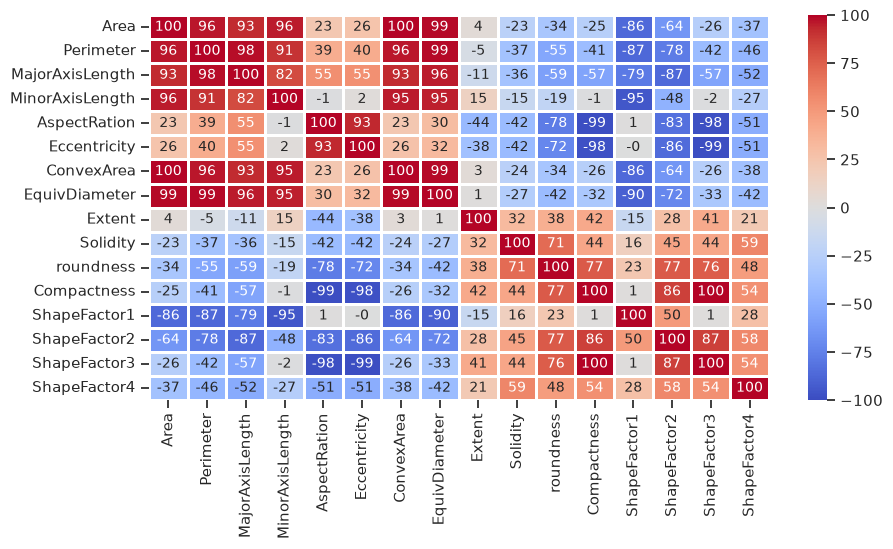

In [5]:
crm = db_dtf.drop(columns=[db_targetname]).corr()
seaborn.heatmap(100*crm, linewidth=.8,
                vmin=-100, vmax=100, cmap="coolwarm",
                annot=True, fmt=".0f", annot_kws={"size":"small"});

We see that some pairs of variables are very strongly correlated either positively or negatively, with absolute several values of correlation above 0.95. For example, `Eccentricity` and `ShapeFactor3` are almost perfectly negatively correlated, having a correlation of 0.99.

### Selecting attributes

For further analysis, we select a subset of attributes with limited pairwise correlations. In particular, we select the six attributes `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `roundness`, `Extent`, `ShapeFactor2`. We narrow down our dataset accordingly.

In [6]:
db_atts = [c for c in db_dtf.columns if c != db_targetname]
db_6atts = ["MajorAxisLength", "MinorAxisLength", "Eccentricity", "roundness", "Extent", "ShapeFactor2"]
db_dtf[db_6atts+[db_targetname]]

,MajorAxisLength,MinorAxisLength,Eccentricity,roundness,Extent,ShapeFactor2,Class
0,208.178117,173.888747,0.549812,0.958027,0.763923,0.003147,SEKER
1,220.804030,186.277756,0.536919,0.945408,0.775806,0.002997,SEKER
2,222.444029,189.980420,0.520175,0.974810,0.788111,0.003013,SEKER
3,234.335001,184.139292,0.618487,0.963681,0.781254,0.002631,SEKER
4,229.774702,190.931594,0.556345,0.937957,0.772203,0.002835,SEKER
...,...,...,...,...,...,...,...
268,271.659919,186.481404,0.727175,0.918880,0.757739,0.001980,DERMASON
269,273.636277,188.219270,0.725858,0.908468,0.811073,0.001963,DERMASON
270,294.946840,176.427866,0.801370,0.885484,0.771669,0.001588,DERMASON
271,293.567969,180.448531,0.788781,0.903968,0.794483,0.001639,DERMASON


### Visualizing the data

For visualizing the data, we will make scatter plots for pairs of attributes. Having six attributes corresponds to fifteen unordered pairs ($(6 \cdot 5)/2$), which would be rather overwhelming if we would plot them all. So we define a list of nine pairs of attributes, which is convenient for plotting in a three-by-three grid.

In [7]:
db_9attpairs = [
    ("MajorAxisLength", "MinorAxisLength"), ("Eccentricity", "MinorAxisLength"), ("roundness","MinorAxisLength"),
    ("MajorAxisLength", "Extent"), ("Eccentricity", "MajorAxisLength"), ("roundness", "MajorAxisLength"),
    ("MajorAxisLength", "ShapeFactor2"), ("Extent", "ShapeFactor2"), ("roundness", "Eccentricity")
]

We select colors to use for plotting the data points grouped by bean variety or otherwise.

In [8]:
db_groupcolors = [
    "#1965B0", "#DC050C", "#F7F056", "#4EB265", "#7BAFDE",
    "#CAE0AB", "#882E72", "#EE8026", "#72190E"
]
seaborn.color_palette(db_groupcolors)

[(0.09803921568627451, 0.396078431372549, 0.6901960784313725),
 (0.8627450980392157, 0.0196078431372549, 0.047058823529411764),
 (0.9686274509803922, 0.9411764705882353, 0.33725490196078434),
 (0.3058823529411765, 0.6980392156862745, 0.396078431372549),
 (0.4823529411764706, 0.6862745098039216, 0.8705882352941177),
 (0.792156862745098, 0.8784313725490196, 0.6705882352941176),
 (0.5333333333333333, 0.1803921568627451, 0.4470588235294118),
 (0.9333333333333333, 0.5019607843137255, 0.14901960784313725),
 (0.4470588235294118, 0.09803921568627451, 0.054901960784313725)]

We define a function to draw a grid of scatter plots, given a dataset together with attributes to use as horizontal and vertical coordinates as well as for color grouping.

In [9]:
def scatter_grid(dtf, coordinates_columns, color_column=None, colors=None, per_row=3, fig_height=None, args_legend=None):
    """Draw a grid of scatter plots.

        Parameters
        ----------
        ddf: DataFrame
            The DataFrame containing the dataset to plot
        coordinates_columns: list of pairs of column names
            The pairs of columns to use as horizontal and vertical coordinates in the scatter plots
        color_column: column name
            The column to determine the groups of data points for coloring
        colors: list of color specifications (e.g. html color codes) or string
            If a list of colors is given, the different groups will be assigned a color from the list, by order of appearance
            If a string is given, it is interpreted as a name of a seaborn color palette.
        per_row: integer
            The number of plots per row
        figheight: float
            Figure height, in inches
        args_legend: dict
            The value at index i is the dict containing legend parameters for the i-th plot.
            If None, or the value at index i is None, the legend is added to the plot, with default parameters
    """

    ## Prepare the color palettes
    if color_column is None:
        color_column = numpy.ones(dtf.shape[0])
        palette = ["#888888"]
        args_legend = {}
    elif type(colors) is list:
        palette = dict([(-1, "#888888")]+[(v, colors[i%len(colors)])
                                          for (i, v) in enumerate([v for v in pandas.unique(dtf[color_column]) if v != -1])])
    else:
        palette = colors

    ## Make the scatter plots
    f, axes = plt.subplots(int(numpy.ceil(len(coordinates_columns)/per_row)), per_row)
    for ci, cc in enumerate(coordinates_columns):
        seaborn.scatterplot(dtf, x=cc[0], y=cc[1],
                        hue=color_column, palette=palette,
                        ax=axes[ci//per_row, ci%per_row], legend=(args_legend is None) or (ci in args_legend))
        if args_legend is not None and args_legend.get(ci) is not None:
            axes[ci//per_row, ci%per_row].legend(**args_legend[ci])
    if fig_height is not None:
        f.set_figheight(fig_height)
    f.tight_layout()

We apply the function to draw a three-by-three grid of scatter plots for the nine pairs of attributes we defined previously.

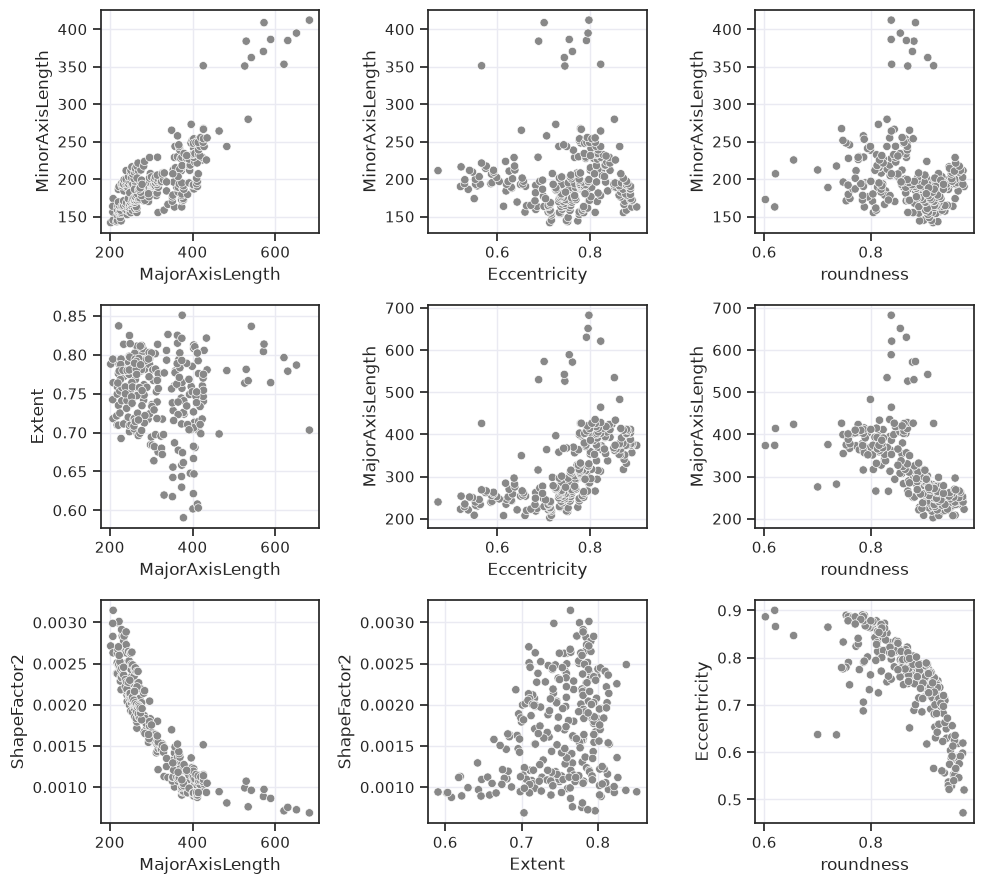

In [10]:
scatter_grid(db_dtf, db_9attpairs, fig_height=9)

We see some correlations between pairs of attributes, e.g. `MajorAxisLength` is strongly positively correlated with 'MinorAxisLength' and negatively with `ShapeFactor2`, while `roundness` and `Eccentricity` are clearly negatively correlated.

The dataset appears to have some clustering structure, as we can see some groups of points, particularly in the `MajorAxisLength` vs. `MinorAxisLength` plots for instance.

We draw the same grid of scatter plots but now with data points grouped and colored by bean variety, using the colors we defined previously.

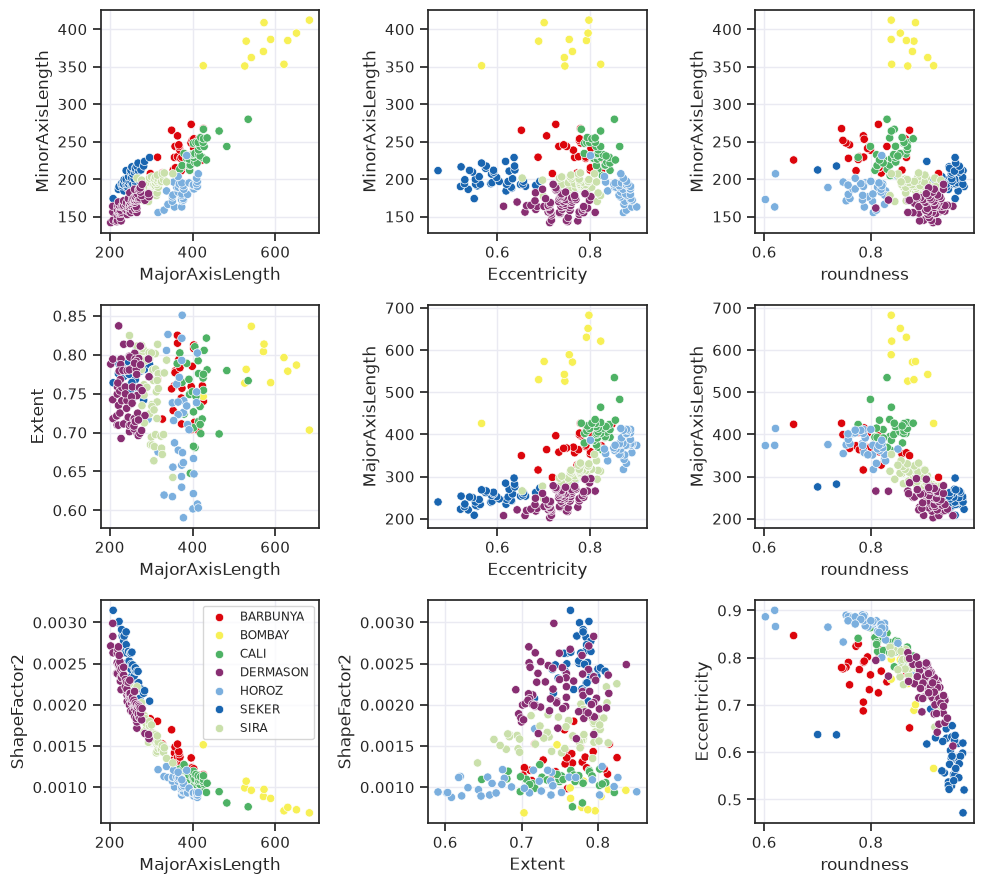

In [11]:
scatter_grid(db_dtf, db_9attpairs, db_targetname, db_groupcolors,
             fig_height=9, args_legend={6: {"loc": "upper right", "fontsize": "x-small"}})

We see some overlap between clouds of points of different colors in most of the plots, for instance between *Barbunya* beans in red and *Cali* beans in green. Also, some groups show a fairly wide spread along some dimensions, such as *extent* measurements for *Horoz* beans (in light blue).
However, we clearly see clustering structure in the data, and that structure seems to agree with the grouping by bean varieties.
*Bombay* beans (in yellow) appear to be significantly larger than beans of the other varieties.

Remember that clustering is an unsupervised machine learning task, meaning that no information about target classes is used for learning. This type of approach is typically used if no reliable ground-truth labels are available, if they are too limited, or to explore ways to group the data points other than by classes.

Here, we are interested to study how various clustering algorithms with different parameters behave on this dataset.
It should be possible to apply clustering algorithms on this dataset while leaving the class labels out, and obtain fairly cohesive clusters.
We can then compare the obtained clusters to the groups formed by beans of different varieties, and hope to obtain a good agreement.

## Clustering with k-means

### Finding four clusters with the six original attributes

First, we try the k-means algorithm, looking for four clusters, i.e. k=4.
The k-means algorithm involves randomness, to initialize the cluster centers. We set the `random_state` parameter to make the experiments repeatable.

We initialize the model and apply it to the dataset by calling the `fit` function on it.

In [12]:
clustering = cluster.KMeans(n_clusters=4, random_state=RS)
clustering.fit(db_dtf[db_6atts])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",RandomState(M...0x74C49A437240
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``."

We store the cluster labels in a new column named after the variant of the dataset used ('6a', for the subset of data consisting of the six selected attributes), the algorithm used ('kmeans') and the number of clusters requested ('4').

We show the sizes of the obtained clusters, sorted by decreasing sizes. We list the cluster indices, in this case integers between *0* and *3*, followed by the size of the cluster, as the number of data points assigned to it, in parentheses.

In [13]:
db_dtf["clusters_6a_kmeans4"] = clustering.labels_
print("\t".join(["%d (%d)" % (k,v) for (k,v) in db_dtf["clusters_6a_kmeans4"].value_counts().items()]))

0 (131)	3 (68)	1 (63)	2 (11)


2. <a id="input_2"></a><span style="background-color:#FEDA8B;">
Edit the following sentence as necessary to ensure it agrees with the output after changing the random seed.
</span>

✏️
The cluster sizes are not perfectly balanced, the largest cluster (cluster *0* with 131 data points) is exactly the same size as the next two together (clusters *3* and *1* with 68+63 data points).

We use our `scatter_grid` function to show a scatter plot of the data points, colored according to their membership in the obtained clusters.

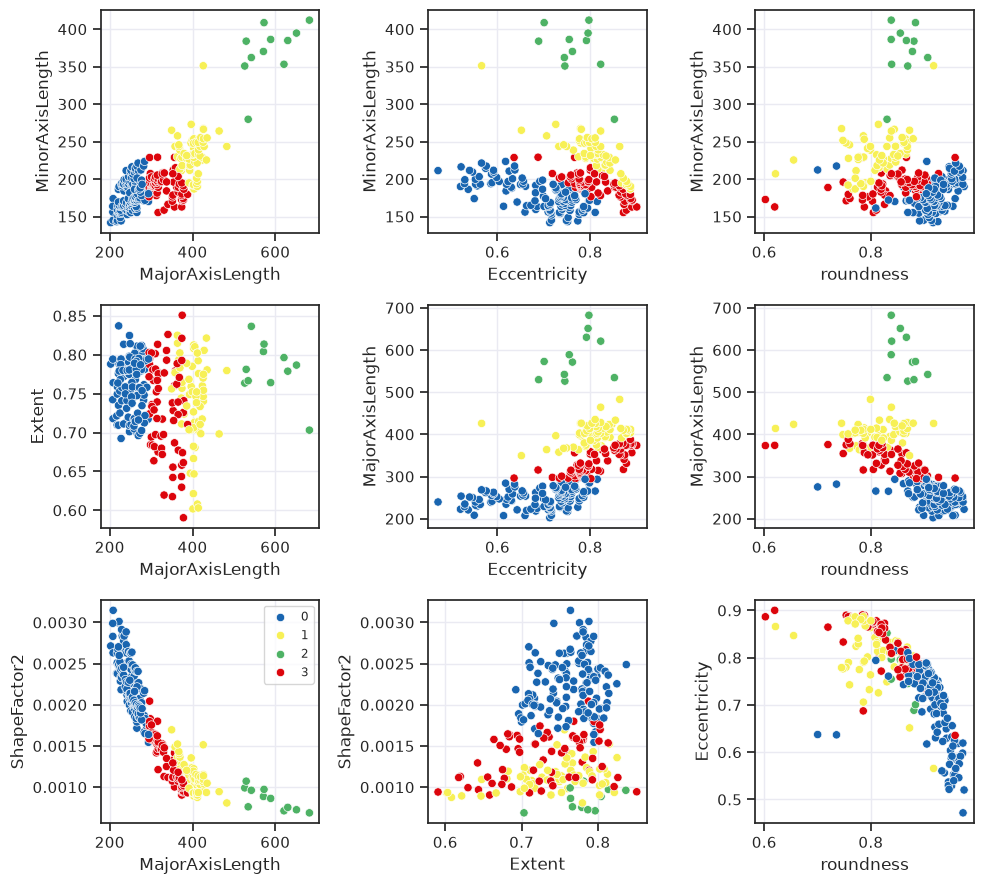

In [14]:
scatter_grid(db_dtf, db_9attpairs, "clusters_6a_kmeans4", db_groupcolors,
             fig_height=9, args_legend={6: {"loc": "upper right", "fontsize": "x-small"}})

Looking at the scatter plots, we notice a scaling issue.
In the plots of the first column, where the horizontal axis represents attribute `MajorAxisLength`, we see that the colors are distributed in vertical strips that do not really follow the structure of the data.
This indicates that the clusters are formed by splitting the data mainly by considering successive intervals of values of `MajorAxisLength`.
Indeed, the main optimization of the k-means algorithm is to minimize the distances of data points to their respective cluster centers. If some attributes are on much larger scales than other, these attributes dominate others in the distance calculations.

### Rescaling the data

To resolve this problem, we generate a rescaled variant of the dataset where we normalize the values of each attribute so that the minimum and maximum values of each attributes are equal to 0 and 1, respectively, as can be seen in the descriptive statistics below.

We append the suffix '_norm' to refer to the normalized attributes. We concatenate the corresponding new columns to the data frame.

In [15]:
db_atts_norm = [c+"_norm" for c in db_atts]
db_dtf = pandas.concat([db_dtf[[db_targetname, "clusters_6a_kmeans4"]+db_atts],
                        pandas.DataFrame(preprocessing.MinMaxScaler().fit_transform(db_dtf[db_atts]),
                                         columns=db_atts_norm, index=db_dtf.index)],
                        axis=1)
db_6atts_norm = [c+"_norm" for c in db_6atts]
db_9attpairs_norm = [(p[0]+"_norm", p[1]+"_norm") for p in db_9attpairs]
db_dtf.describe()

,clusters_6a_kmeans4,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,...,ConvexArea_norm,EquivDiameter_norm,Extent_norm,Solidity_norm,roundness_norm,Compactness_norm,ShapeFactor1_norm,ShapeFactor2_norm,ShapeFactor3_norm,ShapeFactor4_norm
count,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,...,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000
mean,1.058608,53232.278388,858.173322,320.668254,202.502848,1.584150,0.751944,53965.285714,253.426243,0.751571,...,0.155648,0.235205,0.619002,0.810932,0.722111,0.508324,0.583919,0.416585,0.472458,0.741210
std,1.232319,29612.075335,217.525410,85.824118,45.818225,0.247152,0.088447,30072.653087,59.713000,0.048338,...,0.149768,0.166484,0.185704,0.130002,0.176543,0.217376,0.190128,0.242348,0.217844,0.219184
min,0.000000,22449.000000,554.779000,202.216250,141.828980,1.134141,0.471765,22712.000000,169.064942,0.590446,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,36365.000000,706.275000,254.568272,174.902197,1.427524,0.713639,36680.000000,215.177499,0.717934,...,0.069563,0.128565,0.489779,0.742113,0.611723,0.372324,0.480409,0.183290,0.331004,0.655997
50%,1.000000,44628.000000,796.436000,297.981992,192.491117,1.549023,0.763703,45099.000000,238.373938,0.760081,...,0.111492,0.193238,0.651696,0.842041,0.759448,0.514357,0.601090,0.397146,0.470192,0.816034
75%,2.000000,61453.000000,988.821000,374.808751,215.381472,1.708661,0.810850,62238.000000,279.721987,0.787423,...,0.196848,0.308519,0.756736,0.898322,0.850267,0.636513,0.709432,0.607967,0.595607,0.898472
max,3.000000,218738.000000,1810.955000,682.465547,412.081448,2.296656,0.900230,223507.000000,527.736555,0.850744,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Finding four clusters with the six normalized attributes

We run the k-means algorithm again, this time using the six normalized attributes as clustering dimensions, still looking for four clusters.

In [16]:
clustering = cluster.KMeans(n_clusters=4, random_state=RS)
clustering.fit(db_dtf[db_6atts_norm])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",RandomState(M...0x74C49A437240
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``."

We name the column where we store the cluster labels to indicate that the *normalized* version of the six selected attributes were used ('6an').

In [17]:
db_dtf["clusters_6an_kmeans4"] = clustering.labels_
print("\t".join(["%d (%d)" % (k,v) for (k,v) in db_dtf["clusters_6an_kmeans4"].value_counts().items()]))

0 (106)	3 (64)	1 (61)	2 (42)


3. <a id="input_3"></a><span style="background-color:#FEDA8B;">
Edit the following sentence as necessary to ensure it agrees with the output after changing the random seed.
</span>

✏️
Compared to the previous clustering, the cluster sizes are a little more balanced, in particular the largest and smallest clusters are somewhat smaller (106 vs. 131) and larger (42 vs. 11), respectively.

We show a scatter plot of the data points, colored according to their membership in the obtained clusters. We use the pairs of normalized attributes for the axes of the plots (`db_9attpairs_norm` instead of `db_9attpairs` as second parameter).

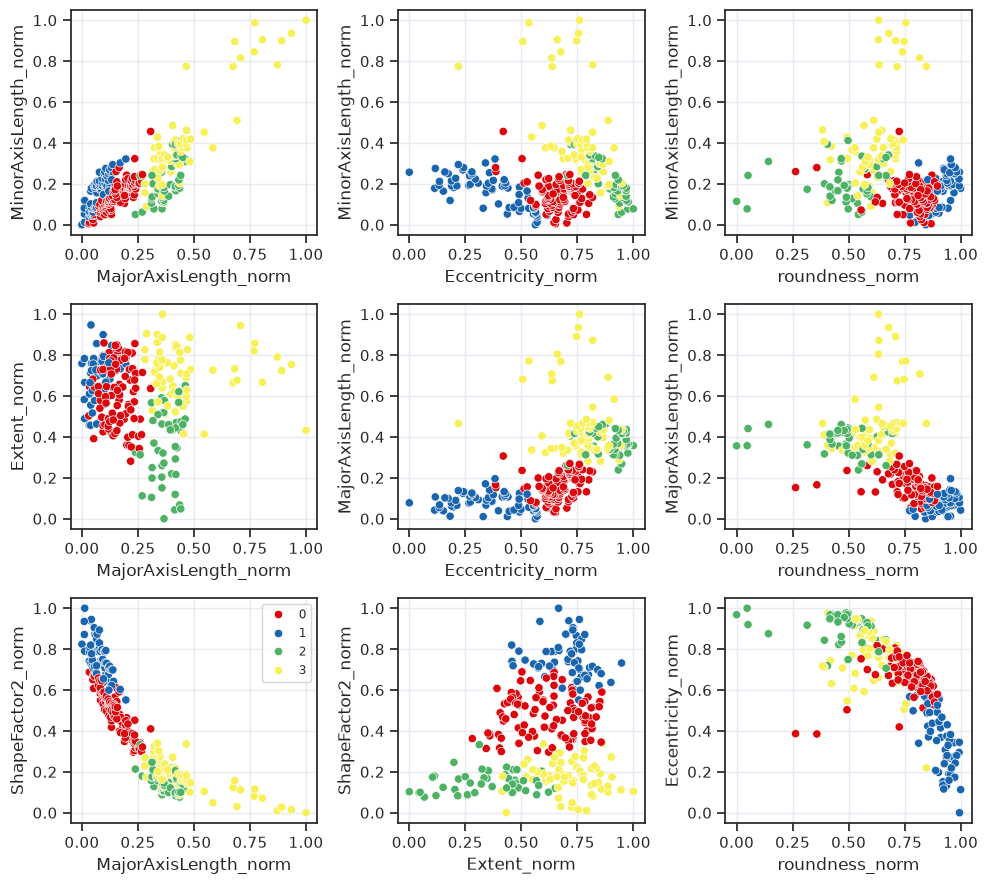

In [18]:
scatter_grid(db_dtf, db_9attpairs_norm, "clusters_6an_kmeans4", db_groupcolors,
             fig_height=9, args_legend={6: {"loc": "upper right", "fontsize": "x-small"}})

We do not see color strips along the `MajorAxisLength_norm` axis, indicating that this attribute no longer dominate the distance calculations. The clusters appear to better follow the data distribution in different dimensions.

The shape of the distribution of data points remains the same whether we use the original or the normalized attributes for plotting.
Indeed, normalizing affects only the relative scale between attributes values.
Since we did not use equal axis aspect ratios in previous figures, meaning that the axes were automatically adjusted for display without preserving the relative scales of the attributes, we do not see any difference in the distributions of the data points.

What pairs of attributes we use to displaying the clusters clearly has no impact on the clusters.
However, it can impact our perception and understanding.
By construction, due to how the algorithms work, the clusters do not overlap in the full dimensional space used when finding them. However, the clusters might appear to overlap when projected onto fewer dimensions for visualization.
Furthermore, if we use different attributes (not just differently scaled) to find the clusters and to visualize them, we might not see the structure and distances that the clustering algorithm relied on.

### Comparing two clusterings

Next, we will compare the two clusterings in more detail, by looking at the differences in how data points are assigned to clusters.

To facilitate such comparisons, we define a `match_clusters` function to match clusters across a pair of clusterings. We consider the contingency matrix (`cm`) where each row corresponds to a cluster in one clustering, each column corresponds to a cluster in the other clustering, and each cell records the number of data points that belong to the two clusters.
We iteratively find the cell with the largest value among unmatched clusters and mark the corresponding clusters as matched.

In [19]:
def match_clusters(cm):
    cm = cm.astype(float)
    match_ids = []
    while not numpy.isnan(cm).all():
        ind = numpy.unravel_index(numpy.nanargmax(cm, axis=None), cm.shape)
        match_ids.append(ind)
        cm[ind[0], :] = numpy.nan
        cm[:, ind[1]] = numpy.nan
    # print(", ".join(["(%d, %d)" % (m[0], m[1]) for m in match_ids]))
    return match_ids

We define a `plot_clustering_comparison` function to make a figure supporting the comparison of a pair of clusterings. The function will draw the contingency matrix to compare the assignments of data points to clusters, with a scatter plot of the clusterings on either side. The `match_clusters` function defined above can be used to depict matching clusters using the same color, to more easily identify the similarities between the clusterings.

We obtain the contingency matrix with  *scikit-learn*'s `metrics.confusion_matrix` function rather than `metrics.cluster.contingency_matrix`, because the former allows to specify which labels to consider when building the matrix, which better suits our purpose.

We also report the value of the *adjusted rand index (ARI)* and *adjusted mutual information (AMI)* calculated between the two clusterings. Both scores measure the similarity between two cluster assignments, not assuming a fixed matching between the clusters. Both scores are symmetric.

The *rand index* is the fraction of pairs of data points such that the two points either are assigned to the same clusters in both clusterings or are assigned to two different clusters in both clusterings, that is, not such that the two points belong to the same cluster in one clustering but different clusters in the other.

The *mutual information* is an information theoretic measure related to the entropy. It measures how much information about one clustering is obtained by observing the other.
Using the same notation as in the lecture, the *mutual information* between two clusterings $\mathcal{C}_A$ and $\mathcal{C}_B$, with respectively $k_A$ and $k_B$ clusters, can be written as
$$\text{MI}(\mathcal{C}_A, \mathcal{C}_B) = \sum_{i\in [1..k_A]} \sum_{j \in [1..k_B]} \frac{\#(a=i, b=j)}{n} \log_2\big(\frac{n \cdot \#(a=i, b=j)}{\#(a=i)\cdot \#(b=j)}\big)\,.$$

The *adjusted rand index (ARI)* and the *adjusted mutual information (AMI)* are variants respectively of the *rand index* and the *mutual information*, adjusted for chance, i.e. so that random assignments receive scores close to zero. More similar clusterings receive larger scores, closer to the upper bound of 1.


In [20]:
def plot_clustering_comparison(dtf, coordinates_columns, lhs_title, lhs_labels, rhs_title, rhs_labels,
                colors=None, color_match=False, lhs_palette=None, rhs_palette=None,
                fig_height=None, args_legend=None):
    """Draw the contingency matrix between scatter plots to compare two clusterings.

        Parameters
        ----------
        ddf: DataFrame
            The DataFrame containing the dataset to plot
        coordinates_columns: a pair of column names
            The columns to use as horizontal and vertical coordinates in the scatter plots
        lhs_title: str
            The title for the clustering displayed on the left-hand side
        lhs_labels: column name
            The column containing the cluster labels for the clustering displayed on the left-hand side
        rhs_title: str
            The title for the clustering displayed on the right-hand side
        rhs_labels: column name
            The column containing the cluster labels for the clustering displayed on the right-hand side
        colors: list of color specifications (e.g. html color codes)
            The different clusters will be assigned a color from the list, by order of appearance
        color_match: bool, 'lhs' or 'rhs'
            Whether to attempt matching clusters and assigning coordinated colors.
            Matching is done by iteratively finding the largest unmatched cells in the contingency matrix.
            If 'lhs' the original color assignment for left-hand side clusters is used and the right-hand side colors are assigned accordingly.
            Vice-versa for 'rhs'. If True, assigns colors in order of matching.
        lhs_palette: dict
            The color palette to use for the left-hand side.
        rhs_palette: dict
            The color palette to use for the right-hand side.
        figheight: float
            Figure height, in inches
        args_legend: dict
            Legend parameters for the scatter plots
    """
    ## Compute the contingency matrix
    lhs_top_label = dtf[lhs_labels].max()
    rhs_top_label = dtf[rhs_labels].max()
    cm = metrics.confusion_matrix(dtf[lhs_labels], dtf[rhs_labels], labels=range(max(lhs_top_label, rhs_top_label)+1))

    ## Prepare the color palettes
    if lhs_palette is None:
        lhs_palette = dict([(-1, "#888888")]+[(v, colors[i%len(colors)])
                            for (i, v) in enumerate([v for v in pandas.unique(dtf[lhs_labels]) if v != -1])])
    if rhs_palette is None:
        rhs_palette = dict([(-1, "#888888")]+[(v, colors[i%len(colors)])
                            for (i, v) in enumerate([v for v in pandas.unique(dtf[rhs_labels]) if v != -1])])
    if color_match != False:
        match_ids = match_clusters(cm)
        if color_match == True:
            lhs_palette = dict([(-1, "#888888")]+[(vlhs, colors[i%len(colors)])
                                                  for (i,(vlhs, vrhs)) in enumerate(match_ids)])
            rhs_palette = dict([(-1, "#888888")]+[(vrhs, colors[i%len(colors)])
                                for (i,(vlhs, vrhs)) in enumerate(match_ids)])
        elif color_match == "rhs" or color_match == 1:
            lhs_palette = dict([(-1, "#888888")]+[(vlhs, rhs_palette.get(vrhs, colors[i%len(colors)]))
                                for (i,(vlhs, vrhs)) in enumerate(match_ids)])
        else:
            rhs_palette = dict([(-1, "#888888")]+[(vrhs, lhs_palette.get(vlhs, colors[i%len(colors)]))
                                for (i,(vlhs, vrhs)) in enumerate(match_ids)])

    ## Create a figure with one row of three plots
    f, axes = plt.subplots(1, 3)

    ## Make the scatter plots
    for (ci, title, color_column, palette) in [(0, lhs_title, lhs_labels, lhs_palette), (2, rhs_title, rhs_labels, rhs_palette)]:
        seaborn.scatterplot(dtf, x=coordinates_columns[0], y=coordinates_columns[1],
                        hue=color_column, palette=palette,
                        ax=axes[ci], legend=(args_legend is None) or (len(args_legend) > 0))
        axes[ci].set_title(title)
        axes[ci].legend(title=None)
        if (args_legend is not None) and (len(args_legend) > 0):
            axes[ci].legend(**args_legend)

    ## Draw the contingency matrix
    seaborn.heatmap(cm[:lhs_top_label+1,:rhs_top_label+1], annot=True, square=True, cmap='magma_r', cbar=False, ax=axes[1])
    axes[1].set_ylabel(lhs_title);
    axes[1].set_xlabel(rhs_title);

    ## Add the similarity scores
    ari = metrics.adjusted_rand_score(dtf[lhs_labels], dtf[rhs_labels])
    ami = metrics.adjusted_mutual_info_score(dtf[lhs_labels], dtf[rhs_labels])
    axes[1].set_title(f"ARI={ari:.3f} AMI={ami:.3f}")

    ## Adjust size
    if fig_height is not None:
        f.set_figheight(fig_height)
    f.tight_layout()

    ## Return the color palettes
    return lhs_palette, rhs_palette

We apply the function to the clusterings obtained by running the k-means algorithm on the original six attributes and on the normalized version, respectively.

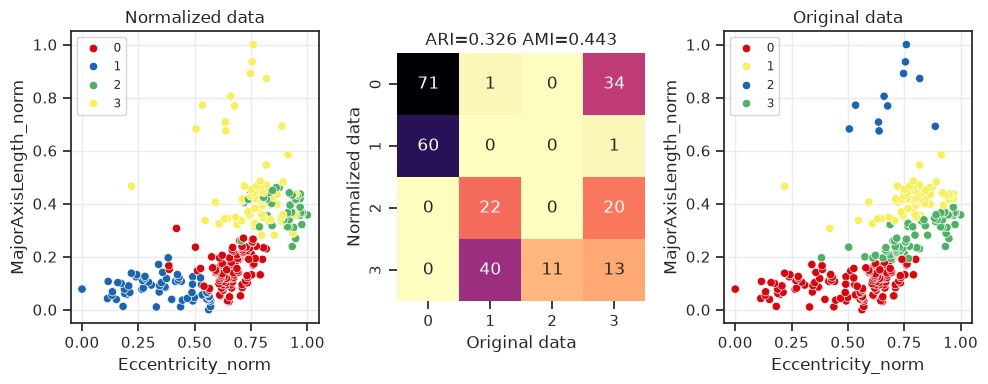

In [21]:
plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "Normalized data", "clusters_6an_kmeans4", "Original data", "clusters_6a_kmeans4",
                colors=db_groupcolors, color_match="lhs", fig_height=4,
                args_legend={"loc": "upper left", "fontsize": "x-small"});

4. <a id="input_4"></a><span style="background-color:#FEDA8B;">
Edit the following couple of paragraphs as necessary to ensure they agree with the output after changing the random seed.
</span>

✏️
The clusters from both clusterings labeled with *0* share the most points across the two clusterings (71), they are the best match and are both depicted in red in the two scatter plots above. With 40 data points in common, cluster *3* from the the clustering on the normalized data (fourth row in the contingency matrix, left-hand side scatter plot) and cluster *1* from the clustering on the original data (second column in the contingency matrix, right-hand side scatter plot) are the next best match, and are both depicted in yellow.

We see significant differences in the assignments. The largest cluster from the original data (in red) is divided almost equally between two clusters from the normalized data (in red and blue).
The ARI and AMI values are fairly low, reflecting this limited agreement.

### Finding eight clusters with the six normalized attributes

We run the k-means algorithm once more, again using the six normalized attributes as clustering dimensions, but looking for eight clusters rather than four.

In [22]:
clustering = cluster.KMeans(n_clusters=8, random_state=RS)
clustering.fit(db_dtf[db_6atts_norm])

,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",RandomState(M...0x74C49A437240
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``."

We store the cluster labels and show the sizes of the obtained clusters.

In [23]:
db_dtf["clusters_6an_kmeans8"] = clustering.labels_
print("\t".join(["%d (%d)" % (k,v) for (k,v) in db_dtf["clusters_6an_kmeans8"].value_counts().items()]))

5 (51)	3 (49)	0 (41)	2 (38)	7 (35)	1 (27)	4 (21)	6 (11)


5. <a id="input_5"></a><span style="background-color:#FEDA8B;">
Edit the following sentence as necessary to ensure it agrees with the output after changing the random seed.
</span>

✏️
The clusters have more balanced sizes though they vary from 51 data points in the largest cluster to 11 in the smallest.

We compare this clustering with eight clusters to the clustering with four clusters also obtained using the six normalized attributes.

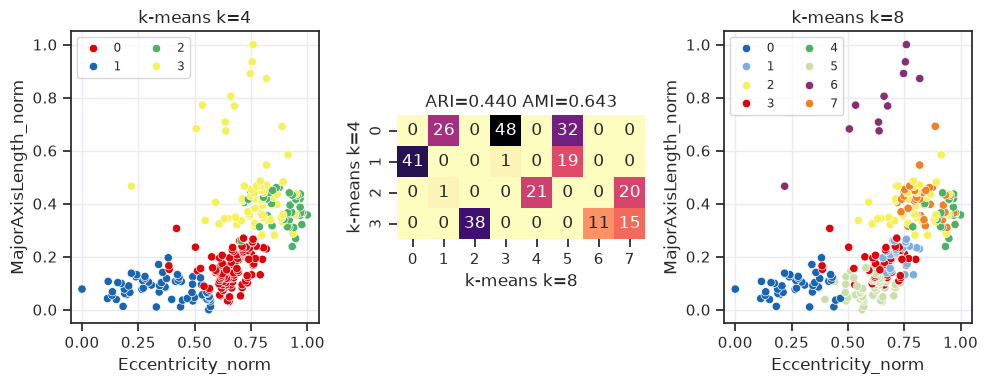

In [24]:
plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "k-means k=4", "clusters_6an_kmeans4", "k-means k=8", "clusters_6an_kmeans8",
                colors=db_groupcolors, color_match="lhs", fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"});

6. <a id="input_6"></a><span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it agrees with the output after changing the random seed.
</span>

✏️
The eight clusters are not obtained strictly by subdividing the four clusters. While clusters *0*, *1*, *2*, *3*, *4* and *6* each consist of data points that essentially all belong to one same cluster among the four (respectively clusters *1*, *0*, *3*, *0*, *4* and *3*), clusters *5* and *7* combine data points from two clusters among the four (*0* and *1* on one hand, *2* and *3* on the other).
It is highly unlikely that the two runs would share some of their initial centers, since they are sampled at random.

## Clustering with agglomerative methods

Next we continue with bottom-up hierarchical methods, i.e. agglomerative methods that work by progressively merging the two closest clusters.

Different merging processes and clusterings are obtained by considering different functions to compute the distance between two clusters, called *linkage functions*, corresponding to different strategies for selecting the pair of clusters to merge at each step.
Here we will consider four linkage functions that are implemented in *scikit-learn*'s `AgglomerativeClustering`, namely
- **complete linkage**, computing the distance between two clusters as the maximum pairwise distance between data points from either clusters,
- **single linkage**, computing the distance between two clusters as the minimum pairwise distance between data points from either clusters,
- **average linkage**, computing the distance between two clusters as the average of pairwise distances between data points from either clusters, and
- **Ward linkage**, computing the distance between two clusters as the variance of the resulting collection of data points.

But first, we need a visualization specific to agglomerative clustering methods.

### Drawing dendrograms

The *dendrogram* is a useful visual representation of the hierarchy of clusters mergers produced by agglomerative methods.
We use a function that draws the dendrogram corresponding to an agglomerative clustering by calling the `dendrogram` function from the *scipy* library (`scipy.cluster.hierarchy`), following [an example from the *scikit-learn* webpage](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html).

In [25]:
from scipy.cluster.hierarchy import dendrogram
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = numpy.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = numpy.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    if "link_color_func" not in kwargs:
        kwargs["link_color_func"] = lambda k: "#888888"
    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

### Complete linkage

We start by considering complete linkage as the linkage function, defining the distance between two sets of points to be the maximum distance between any pair of points they contain, i.e. the distance between the two points from either sets that are furthest from each other.

To study the full merging process, from singleton clusters consisting each of an individual data point, all the way to a single cluster containing all data points, we apply the agglomerative clustering algorithm without a number of clusters and setting the distance threshold to zero.

We initialize the model accordingly, and apply it to the dataset.

In [26]:
agg_clusterings = {}
agg_clusterings["complete"] = cluster.AgglomerativeClustering(linkage="complete",
                                                              distance_threshold=0, n_clusters=None)
agg_clusterings["complete"].fit(db_dtf[db_6atts_norm])

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'complete'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_s

We apply the `plot_dendrogram` function on the fitted model, to visualize the entire hierarchy of clusters as a dendrogram.
With one leaf node per data point, there are too many to distinguish them individually, so we deactivate labeling.

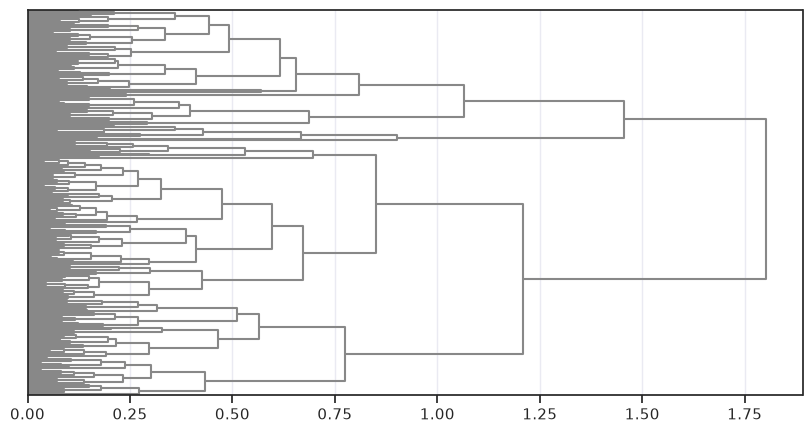

In [27]:
plot_dendrogram(agg_clusterings["complete"], orientation='right', no_labels=True)

Each inner node represents the merger of the two clusters corresponding to the two child branches, with the horizontal position of the node and the vertical line joining the branches indicating the distance between the two clusters as measured with the chosen linkage function, in this case the complete linkage.
The right-most vertical line represents the final merger, joining the last two clusters together into a single cluster containing all data points. The corresponding complete linkage distance is about 1.80, meaning that the two points from the last two clusters that are the furthest apart, and hence the pair of points furthest apart in the dataset overall, are at a distance of 1.80 from each other.

Though we cannot identify individual nodes and track how they are progressively merged, the dendrogram allows us to see the general structure of the process.

We check the distances of the last mergers...

In [28]:
agg_clusterings["complete"].distances_[-7:]

array([0.80786145, 0.84933024, 0.90215333, 1.06525063, 1.20783235,
       1.45660155, 1.8009351 ])

... and show the zoomed-in part representing the merger of the last eight clusters into a single one, by plotting the dendrogram again now setting parameters `truncate_mode` and `p` to 'lastp' and '8', respectively.

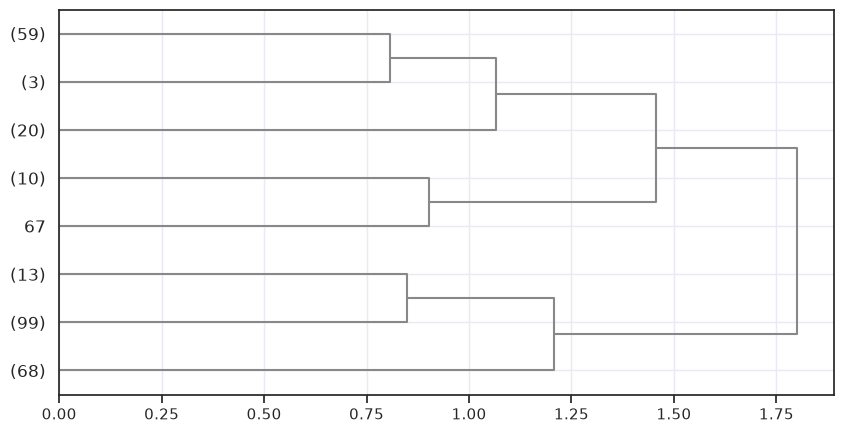

In [29]:
plot_dendrogram(agg_clusterings["complete"], orientation='right', truncate_mode="lastp", p=8)

Labels on the left-hand side represent clusters, values between parentheses indicate the number of data points in the corresponding cluster, whereas values without parentheses represent singleton clusters and indicate the index of the corresponding data point.

From the last eight clusters, seven clusters are obtained by merging two clusters containing respectively 59 and 3 data points, such that the furthest pair are at a distance of about 0.81.
Merging two other clusters containing respectively 13 and 99 data points and at a complete linkage distance of 0.85 leaves us with six clusters. Then, singleton cluster *67* is merged with a cluster containing 10 data points, the further of which is at distance 0.90 of data point *67*. At that stage, five clusters remain and the process continues until there is only one left.

The leaf nodes in the dendrogram above corresponds to the clustering obtained when running the agglomerative clustering algorithm with complete linkage while setting the desired number of clusters to eight.

In [30]:
clustering = cluster.AgglomerativeClustering(linkage="complete", n_clusters=8)
clustering.fit(db_dtf[db_6atts_norm])

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",8
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'complete'
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_s

We store the cluster labels and show the sizes of the obtained clusters.

In [31]:
db_dtf["clusters_6an_complete8"] = clustering.labels_
print("\t".join(["%d (%d)" % (k,v) for (k,v) in db_dtf["clusters_6an_complete8"].value_counts().items()]))

6 (99)	0 (68)	4 (59)	1 (20)	2 (13)	3 (10)	7 (3)	5 (1)


The cluster sizes indeed match with the values seen on the left-hand side of the dendrogram. The cluster sizes are not very balanced, with the largest cluster containing 99 data points and the smallest cluster being a singleton.

We show a scatter plot of the data points, colored according to their membership in the eight obtained clusters.

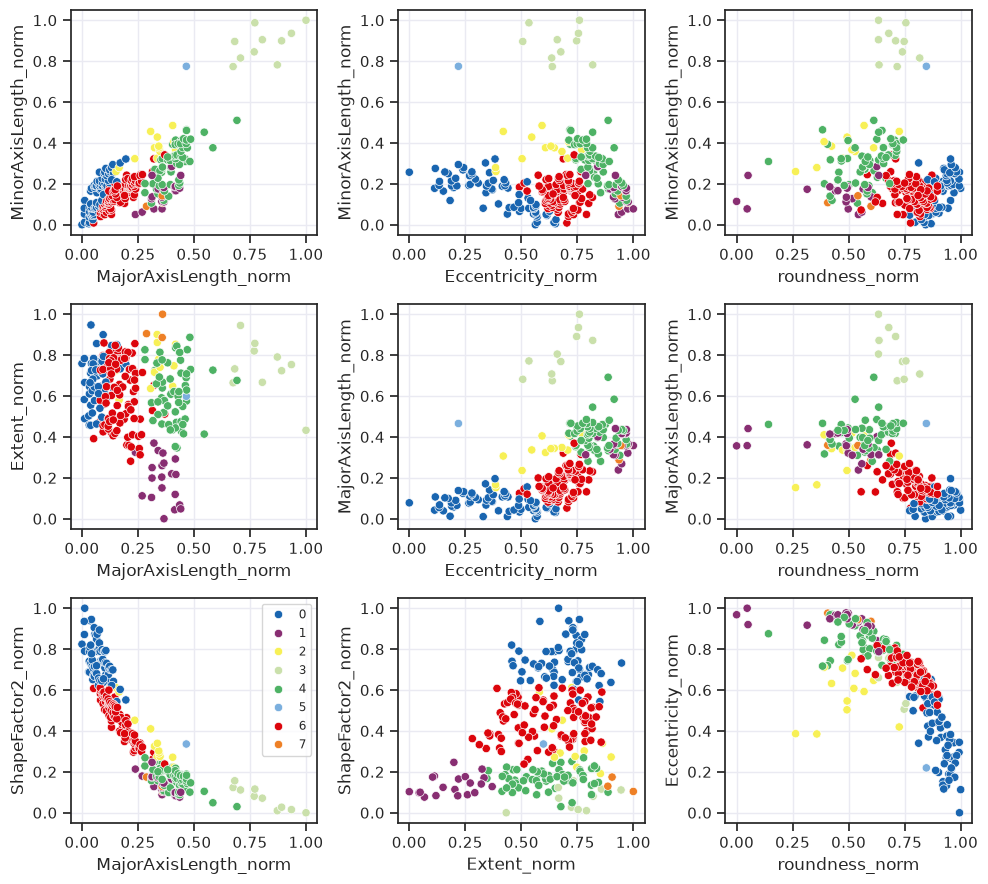

In [32]:
scatter_grid(db_dtf, db_9attpairs_norm, "clusters_6an_complete8", db_groupcolors,
             fig_height=9, args_legend={6: {"loc": "upper right", "fontsize": "x-small"}})

We can clearly see the singleton cluster, labelled *5* with its single data point depicted in light blue. This data point has a `MinorAxisLength` value similar to the data points of cluster *3* (light green) and appears quite close to them in the plots of the first row, but its values for other attributes are different and it appears more distant from that cluster in other plots.

### Comparing linkage functions

In order to compare agglomerative clustering with different linkage function, we run the clustering algorithm in turn with single linkage, average linkage and Ward linkage. We do not set the number of clusters and set the distance threshold to zero to get the full cluster hierarchy.

In [33]:
agg_clusterings["single"] = cluster.AgglomerativeClustering(linkage="single", distance_threshold=0, n_clusters=None)
agg_clusterings["single"].fit(db_dtf[db_6atts_norm])

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'single'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sam

In [34]:
agg_clusterings["average"] = cluster.AgglomerativeClustering(linkage="average", distance_threshold=0, n_clusters=None)
agg_clusterings["average"].fit(db_dtf[db_6atts_norm])

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'average'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sa

In [35]:
agg_clusterings["ward"] = cluster.AgglomerativeClustering(linkage="ward", distance_threshold=0, n_clusters=None)
agg_clusterings["ward"].fit(db_dtf[db_6atts_norm])

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sampl

We display dendrograms for the four linkage functions (one per row). For each we display the full dendrogram (left) as well as zoomed-in versions showing the merging of the last 32 clusters (middle) and of the last 8 clusters (right).

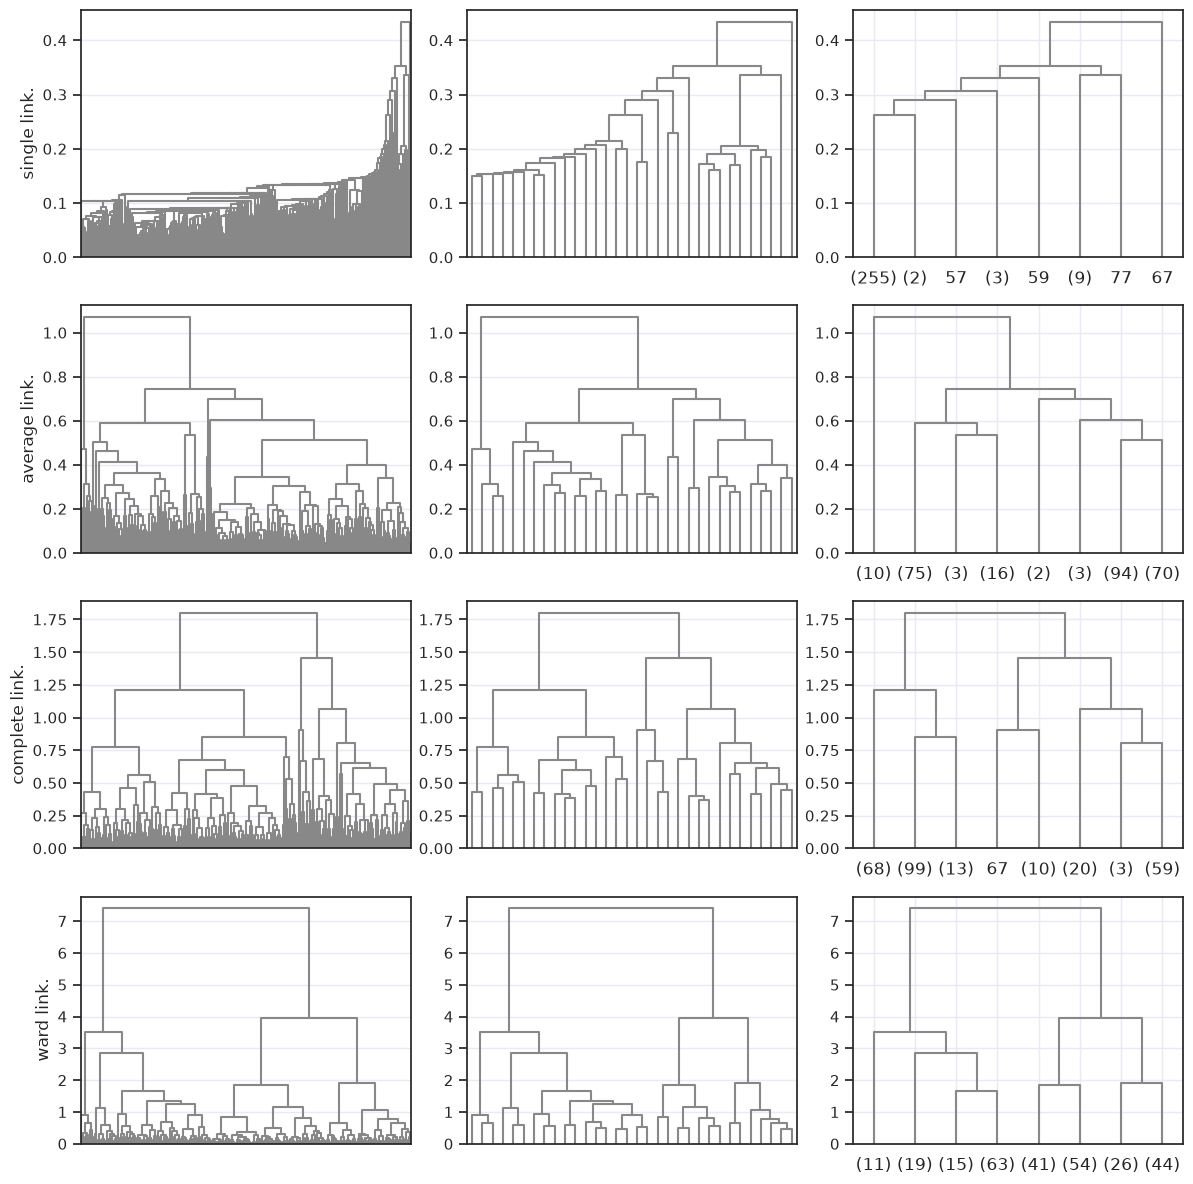

In [36]:
f, axes = plt.subplots(4, 3)
for ci, name in enumerate(["single", "average", "complete", "ward"]):
    plot_dendrogram(agg_clusterings[name], orientation='top', no_labels=True, ax=axes[ci,0])
    plot_dendrogram(agg_clusterings[name], orientation='top', truncate_mode="lastp", p=32, no_labels=True, ax=axes[ci,1])
    plot_dendrogram(agg_clusterings[name], orientation='top', truncate_mode="lastp", p=8, ax=axes[ci,2])
    axes[ci, 0].set_ylabel(f"{name} link.")
f.set_figwidth(12)
f.set_figheight(12)
f.tight_layout()

7. <a id="input_7"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the dendrograms, and to explain what they mean in terms of how the hierarchical merging unfolds with the different linkage functions.
</span>

✏️
...

We obtain the clusterings corresponding to the dendrograms in the right-hand side column, with eight clusters.

In [37]:
for name in ["single", "average", "complete", "ward"]:
    if name != "complete": # previously computed
        clustering = cluster.AgglomerativeClustering(linkage=name, n_clusters=8)
        clustering.fit(db_dtf[db_6atts_norm])
        db_dtf[f"clusters_6an_{name}8"] = clustering.labels_
    print("\t".join(["% 10s" % name]+["%d (%d)" % (k,v) for (k,v) in db_dtf[f"clusters_6an_{name}8"].value_counts().items()]))

    single	1 (255)	3 (9)	0 (3)	2 (2)	6 (1)	4 (1)	7 (1)	5 (1)
   average	7 (94)	0 (75)	2 (70)	5 (16)	1 (10)	4 (3)	6 (3)	3 (2)
  complete	6 (99)	0 (68)	4 (59)	1 (20)	2 (13)	3 (10)	7 (3)	5 (1)
      ward	0 (63)	1 (54)	2 (44)	6 (41)	5 (26)	4 (19)	3 (15)	7 (11)


We compare the cluster assignments obtained with the complete linkage and the average linkage.

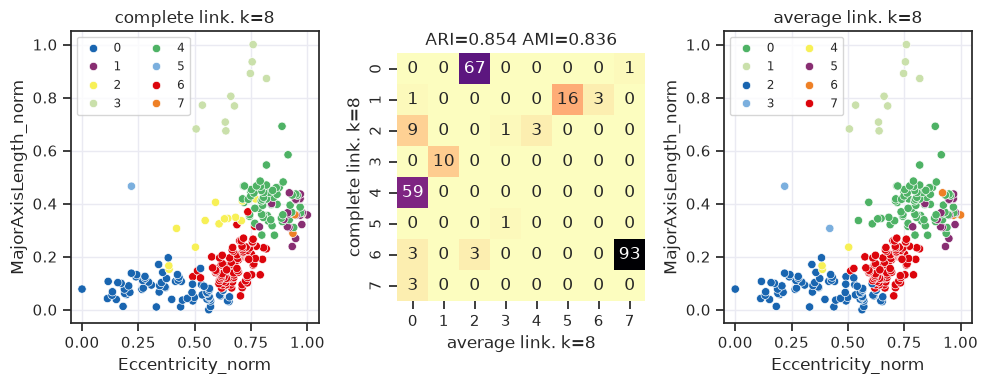

In [38]:
comp_palette, avg_palette = plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "complete link. k=8", "clusters_6an_complete8", "average link. k=8", "clusters_6an_average8",
                colors=db_groupcolors, color_match="lhs", fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"})

We see a high agreement between the clusterings, with the ARI and AMI scores reaching 0.854 and 0.836, respectively.

The values in the contingency table are concentrated in a few cells, with very good matches in particular of complete linkage clusters *6* (depicted in red in the left-hand side scatter plot, seventh row in the contingency matrix), *0* (blue) and *4* (green) with average linkage clusters *7* (depicted in red in the right-hand side scatter plot, eighth column in the contingency matrix), *2* (blue) and *0* (green), respectively.
The main differences between the assignments are for points with `MajorAxisLength` values in the medium range, between 350 and 450.

We compare the cluster assignments obtained with complete linkage and Ward linkage.

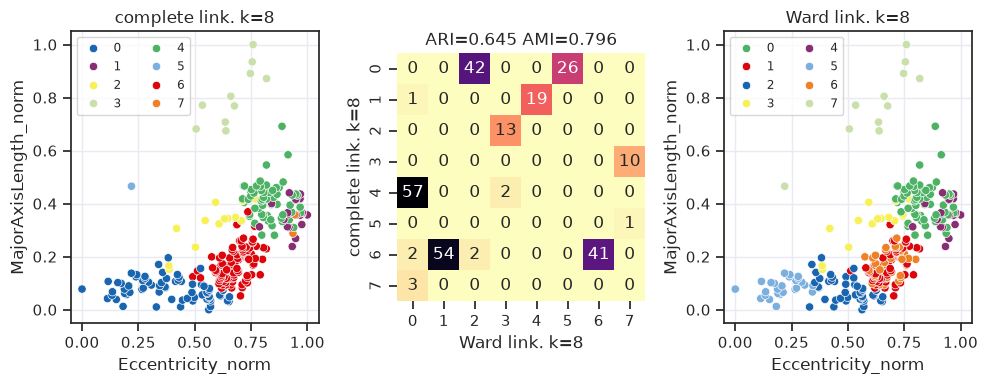

In [39]:
plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "complete link. k=8", "clusters_6an_complete8", "Ward link. k=8", "clusters_6an_ward8",
                colors=db_groupcolors, color_match="lhs", lhs_palette=comp_palette, fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"});

8. <a id="input_8"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations comparing the complete linkage and the Ward linkage cluster assignments.
</span>

Finally, we compare the cluster assignments obtained with the single linkage and the average linkage.

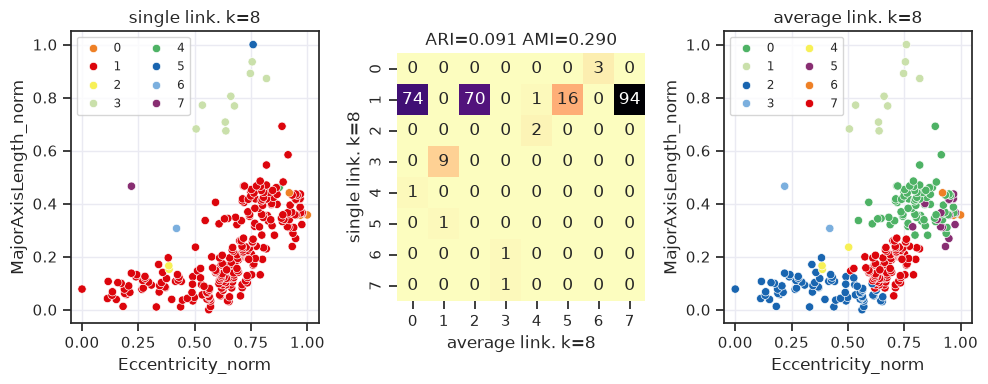

In [40]:
plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "single link. k=8", "clusters_6an_single8", "average link. k=8", "clusters_6an_average8",
                colors=db_groupcolors, color_match="rhs", rhs_palette=avg_palette, fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"});

9. <a id="input_9"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations comparing the single linkage and the average linkage cluster assignments.
</span>

✏️
...

10. <a id="input_10"></a><span style="background-color:#FEDA8B;">
Write a few sentences to tie together and summarize your observations about the dendrograms and the obtained cluster assignments for the different linkage functions.
</span>

✏️
...

## Clustering with DBSCAN

Finally, we consider a density based clustering method, namely *Density-Based Spatial Clustering of Applications with Noise (DBSCAN)*.

Note that with this method, we do not specify the number of desired clusters, instead we specify parameters that determine which points are considered to be located in dense regions, forming clusters.
Also, with this method, some points lying in sparser regions might be considered outliers and not be assigned to any clusters.

First, we try setting parameters `eps` (a.k.a. epsilon, $\epsilon$), that defines the radius of a point's neighborhood, and `min_samples` (a.k.a. tau, $\tau$), that defines the number of data points that must lie within this neighborhood for the point to be considered as belonging to a dense region, respectively to 0.1 and 4.

We initialize the model and apply it to the dataset.

In [41]:
clustering = cluster.DBSCAN(eps=0.1, min_samples=4)
clustering.fit(db_dtf[db_6atts_norm])

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.1
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",4
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](105, 6)","[[0.04,0.16,0.15,0.92,0.71,0.94], [0.07,0.16,0.34,0.97,0.73,0.79], [0.06,0.18,0.2 ,0.9 ,0.7 ,0.87], ..., [0.15,0.17,0.59,0.82,0.85,0.52], [0.19,0.13,0.77,0.76,0.7 ,0.37], [0.19,0.14,0.74,0.81,0.78,0.39]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](105,)","[ 1, 3, 4,...,269,270,271]"


We store the cluster labels and show the sizes of the obtained clusters.

In [42]:
db_dtf["clusters_6an_dbscan-e.10-t4"] = clustering.labels_
print("\t".join(["%d (%d)" % (k,v) for (k,v) in db_dtf["clusters_6an_dbscan-e.10-t4"].value_counts().items()]))

-1 (131)	4 (93)	0 (20)	2 (11)	1 (7)	3 (6)	5 (5)


Label *-1* does not represent an actual cluster, but identifies outliers. In this case, almost half of the data points (131 out of 273) have not been assigned to any clusters. The remaining half have been divided into six clusters, one large, namely cluster *4* containing 93 data points, and five smaller ones, containing between 20 and 5 data points.

We show scatter plots of the data points, colored according to their membership in the six obtained clusters or their outlier status.

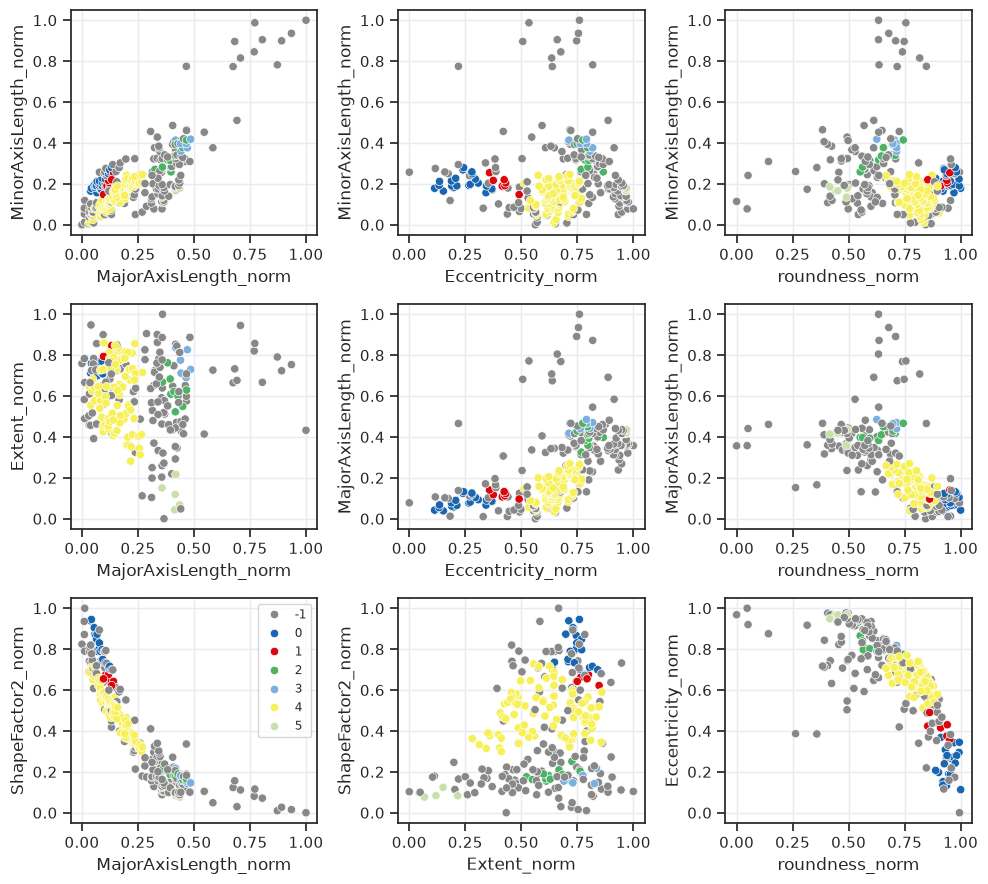

In [43]:
scatter_grid(db_dtf, db_9attpairs_norm, "clusters_6an_dbscan-e.10-t4", db_groupcolors,
             fig_height=9, args_legend={6: {"loc": "upper right", "fontsize": "x-small"}})

Outliers are depicted in gray, and indeed constitute a large proportion of the data points scattered throughout the range of values.
The fact that many data points are left out of the cluster assignment limits its potential interest and usefulness.

We try to adjust the parameters. We increase the neighborhood radius so that more points might be included, setting `eps` to 0.15, and increasing the number of neighbors to try to avoid too many points being clumped together, setting `min_samples`.

We initialize the model with adjusted parameters and apply it to the dataset.

In [44]:
clustering = cluster.DBSCAN(eps=0.15, min_samples=6)
clustering.fit(db_dtf[db_6atts_norm])

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.15
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",6
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](179, 6)","[[0.04,0.16,0.15,0.92,0.71,0.94], [0.04,0.18,0.11,1. ,0.76,0.95], [0.07,0.16,0.34,0.97,0.73,0.79], ..., [0.19,0.13,0.77,0.76,0.7 ,0.37], [0.19,0.14,0.74,0.81,0.78,0.39], [0.16,0.19,0.58,0.9 ,0.63,0.51]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](179,)","[ 1, 2, 3,...,270,271,272]"


Again, we store the cluster labels, show the sizes of the obtained clusters...

In [45]:
db_dtf["clusters_6an_dbscan-e.15-t6"] = clustering.labels_
print("\t".join(["%d (%d)" % (k,v) for (k,v) in db_dtf["clusters_6an_dbscan-e.15-t6"].value_counts().items()]))

0 (162)	1 (62)	-1 (41)	2 (8)


... and visualize the cluster assignment using scatter plots.

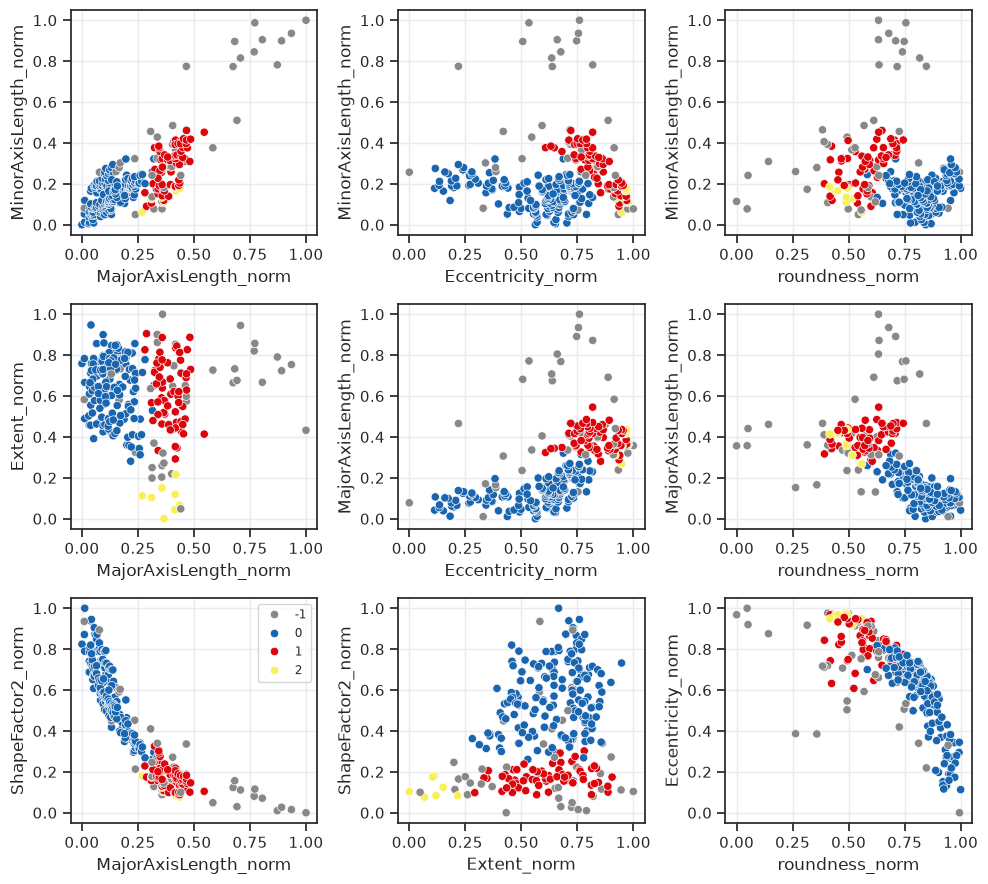

In [46]:
scatter_grid(db_dtf, db_9attpairs_norm, "clusters_6an_dbscan-e.15-t6", db_groupcolors,
             fig_height=9, args_legend={6: {"loc": "upper right", "fontsize": "x-small"}})

11. <a id="input_11"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the clusters obtained with the alternative parameterization of the DBSCAN algorithm.
</span>

✏️
...

We compare the two clusterings using the `plot_clustering_comparison` function. Note that outliers are not included in the contingency matrix, but that -1 is considered like a regular cluster label, i.e. outliers are considered as an additional cluster in either clustering, when computing the ARI and AMI scores.

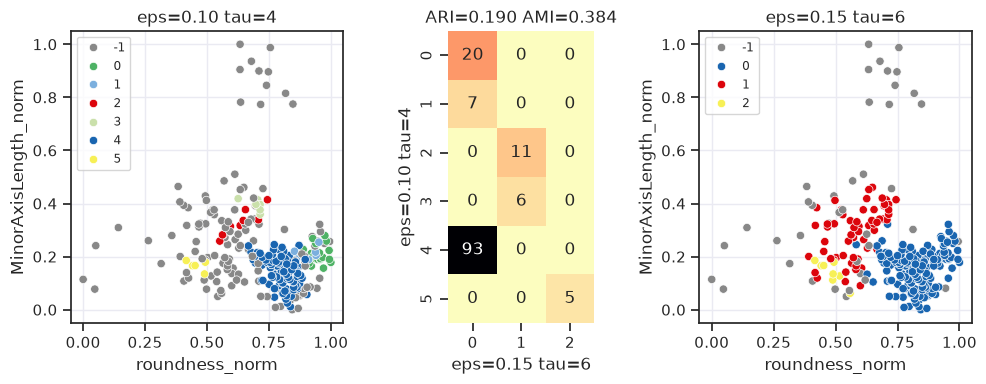

In [47]:
plot_clustering_comparison(db_dtf, db_9attpairs_norm[2],
                "eps=0.10 tau=4", "clusters_6an_dbscan-e.10-t4", "eps=0.15 tau=6", "clusters_6an_dbscan-e.15-t6",
                colors=db_groupcolors, color_match=True, fig_height=4,
                args_legend={"loc": "upper left", "fontsize": "x-small"});

12. <a id="input_12"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations comparing the two cluster assignments obtained with the DBSCAN algorithm.
</span>

✏️
...

## Evaluation

Now that we have a collection of clusterings obtained by applying various methods on the same dataset, let us do an evaluation, relying on quantitative measures, not just eyeballing.

### Internal validation criteria

First, we evaluate the clusterings using internal validation criteria, i.e. measures that capture intrinsic properties of the clusterings, as opposed to comparing them to an expected result.

Ideally, clusters should be compact, if we consider the average of each cluster as its centroid, all points should be close to the center of the cluster they are assigned to. In other words, the sum of (square) distances to the cluster centroids should be small.
The *sum of square distances to centroids (SSDC)*, also known as *inertia*, is actually the criterion optimized by the k-means algorithm, which returns the centroids as well as the achieved *inertia* along with the clustering (as the model's fitted attributes `cluster_centers_` and `inertia_`, respectively).
For other algorithms, we can similarly determine centroids for the obtained clusters and calculate the sum of square distances.

We define our own `inertia_score` function to compute this score for a clustering, given the matrix of attribute values and the vector of labels representing the cluster assignment.

In [48]:
def inertia_score(X, labels):
    centroids = []
    distances = []
    for i in numpy.unique(labels):
        if i != -1:
            centroids.append(X[labels==i].mean(axis=0))
            distances.append(numpy.sum([(X.loc[labels==i, c]-centroids[-1][c])**2 for c in X.columns]))
    return float(numpy.sum(distances))#, distances, centroids

Clusters should be such that two points belonging to the same clusters are more similar to each other than two points belonging to different clusters.
Hence, one way to evaluate the intrinsic quality of a clustering is to compute the ratio between the average of distances between pairs of points belonging to the same cluster and the average of distances between pairs belonging to different clusters, i.e. the *intra-cluster to inter-cluster distance ratio*, or just *distance ratio* for short. The smaller the value of this ratio, the more cohesive the clusters.

We define our own `distance_ratio_score` function to compute this score for a clustering, given the matrix of pairwise distances between the data points and the vector of labels representing the cluster assignment.

In [49]:
def distance_ratio_score(pdists, labels):
    Ct = numpy.tile(labels.to_numpy(), (len(labels), 1))
    Ct[numpy.eye(len(labels), len(labels), dtype=bool)==1] = -1
    return numpy.mean(pdists[(Ct != -1) & (Ct == Ct.T)])\
          /numpy.mean(pdists[(Ct != -1) & (Ct.T != -1) & (Ct != Ct.T)])

We compute the matrix of pairwise distances between the data points over the six normalized selected attributes and store it for later use.

In [50]:
pdists_6atts_norm = metrics.pairwise.pairwise_distances(db_dtf[db_6atts_norm])

Another evaluation measure is the *silhouette score* which also compares distances between points in the same cluster versus in different clusters. This score takes values between -1 and 1, with 1 the best value.

We consider all clusterings obtained using the six normalized selected attributes as clustering data, that is, all label vectors stored as columns under a name starting with 'clusters_6an_'.
When calculating distances to compute the scores, we also use the six normalized selected attributes as coordinates for the data points.
In addition to the three scores, we also record the number of outliers, the number of clusters, as well as the minimum and maximum cluster sizes.

We show the table of results, sorting the clusterings by increasing distance ratio, i.e. from best to worst according to this distance criterion.

In [51]:
clusterings = [c for c in db_dtf.columns if c.startswith("clusters_6an_")]
evl_stats = []
for c in clusterings:
    csizes = dict(db_dtf[c].value_counts().items())
    nb_outliers = csizes.pop(-1, 0)
    evl_stats.append([c, nb_outliers,
        len(csizes), min(csizes.values()), max(csizes.values()),
        inertia_score(db_dtf[db_6atts_norm], db_dtf[c]), distance_ratio_score(pdists_6atts_norm, db_dtf[c]),
        metrics.silhouette_score(db_dtf[db_6atts_norm], db_dtf[c])
        ])

eval_dtf = pandas.DataFrame(evl_stats,
                            columns=["name", "nb_outliers", "nb_clusters", "min_size", "max_size",
                                     "inertia_6an", "distance_ratio_6an", "silhouette_6an"])
eval_dtf.sort_values(by=["distance_ratio_6an"], ascending=True)

,name,nb_outliers,nb_clusters,min_size,max_size,inertia_6an,distance_ratio_6an,silhouette_6an
1,clusters_6an_kmeans8,0,8,11,51,10.896733,0.382963,0.308747
5,clusters_6an_ward8,0,8,11,63,11.545729,0.402508,0.300073
2,clusters_6an_complete8,0,8,1,99,14.292888,0.426851,0.310942
4,clusters_6an_average8,0,8,2,94,14.214297,0.429358,0.346800
6,clusters_6an_dbscan-e.10-t4,131,6,5,93,4.868557,0.443295,-0.115427
0,clusters_6an_kmeans4,0,4,42,106,20.422820,0.478081,0.324549
7,clusters_6an_dbscan-e.15-t6,41,3,8,162,19.039482,0.546735,0.281799
3,clusters_6an_single8,0,8,1,255,47.915489,0.567306,-0.044205


13. <a id="input_13"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the scores obtained for the different clusterings shown above, and to explain what they mean in terms of the quality of the clusters.
Are the values of a given score obtained for different clusterings comparable?
</span>

### Comparison to grouping by bean varieties

In fact the data contains class labels, indicating to which bean variety each specimen belongs to. We can use this as a reference against which to compare the clusterings we obtained.

Let us retrieve the class labels from the dataset. For ease of processing, we will use the numerical codes as labels rather than the names of the varieties in text form. We show the mapping between numerical labels and bean varieties.

In [52]:
db_dtf["clusters_bean_varieties"] = db_dtf[db_targetname].cat.codes
print("\t".join(["%d: % 5s" % (i, v) for i, v in enumerate(db_dtf[db_targetname].cat.categories)]))

0: BARBUNYA	1: BOMBAY	2:  CALI	3: DERMASON	4: HOROZ	5: SEKER	6:  SIRA


We can compare a chosen clustering to this reference. For example, let us compare the four clusters obtained with the k-means algorithm run on the six normalized attributes.

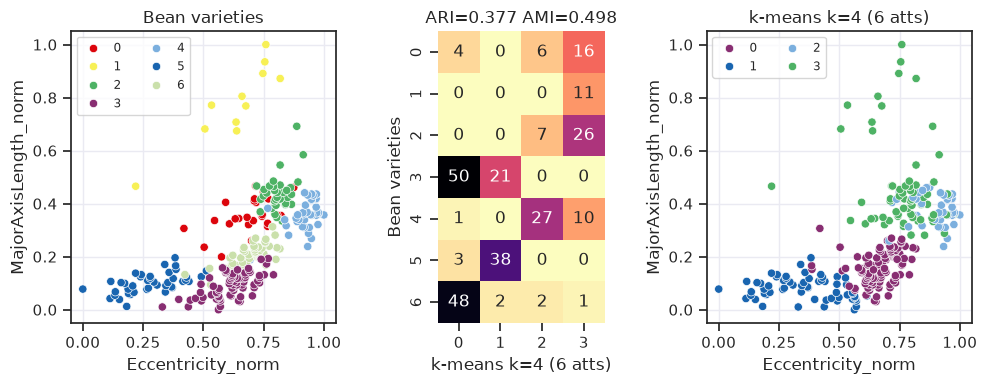

In [53]:
plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "Bean varieties", "clusters_bean_varieties", "k-means k=4 (6 atts)", "clusters_6an_kmeans4",
                colors=db_groupcolors, color_match="lhs", fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"});

The considered clustering consists of fewer clusters than there are bean varieties in the reference, so obviously we cannot get a one-to-one match. The best we could hope for, to reach the highest agreement, would be that all data points representing beans of the same variety would be assigned to the same k-means cluster, with two pairs of varieties joined into one cluster each, to account for the limited number of clusters.

14. <a id="input_14"></a><span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it agrees with the output after changing the random seed.
</span>

✏️
This is not quite what we observe. Some varieties are indeed mostly assigned to one cluster. For instance, the vast majority of beans of variety *6* (bottom row of the contingency matrix, light green in the left-hand side scatter plot), i.e. variety *Sira*, are assigned to cluster *0* (first column of the contingency matrix, purple in the right-hand side scatter plot), specifically 48 out of 53 instances. But some varieties are divided into different clusters. For instance, fifty of the seventy-one instances of variety *3* are assigned to clusters *0* with the remaining twenty-one assigned to cluster *1*.
Overall, the agreement is not very high, achieving an AMI just below 0.5 the middle value between a random assignment and a perfectly matching assignment.

Since we know how many different varieties of beans the reference contains, we might use that as the desired number of clusters, and see how well the different algorithm can match the grouping by bean varieties when this information is assumed.

Furthermore, we can compare the clusterings obtained when using different sets of attributes. In particular, we consider two other sets of attributes
beside the six selected attributes (`db_6atts_norm`) that we have used previously. On one hand, we consider a subset consisting of the first four of those attributes (`db_6atts_norm[:-2]`), excluding `Extent`, which does not seem very useful to determine the bean variety, as well as `ShapeFactor2`. On the other hand, we consider the superset consisting of all sixteen attributes (`db_atts_norm`). We always use the normalized versions of the attributes.

We re-run the clustering algorithms, excluding the agglomerative clustering with single linkage and the DBSCAN algorithm, which behaved poorly.

Because the k-means algorithm involves randomness, repeated runs might give different results. To see how much the results can vary, we run the k-means algorithm three times for each setup.

In [54]:
k = len(set(db_dtf["clusters_bean_varieties"]))
for atts in [db_atts_norm, db_6atts_norm, db_6atts_norm[:-2]]:
    for i in range(3):
        clustering = cluster.KMeans(n_clusters=k, random_state=RS)
        clustering.fit(db_dtf[atts])
        db_dtf[f"clusters_{len(atts)}an_kmeans({i}){k}"] = clustering.labels_

    for linkage in ["average", "complete", "ward"]:
        clustering = cluster.AgglomerativeClustering(linkage=linkage, n_clusters=k)
        clustering.fit(db_dtf[atts])
        db_dtf[f"clusters_{len(atts)}an_{linkage}{k}"] = clustering.labels_

We consider all clusterings consisting of seven clusters, that is, all label vectors stored as columns under a name starting with 'clusters_' and ending with '7'.

We compute different versions of the distance-based internal validation criteria, one for each set of attributes (`atts`, `6atts` and `4atts`).
In addition to the three versions of each of these three scores, we also record the *adjusted rand index (ARI)* and *adjusted mutual information (AMI)* score computed by comparing the clustering to the reference grouping by bean varieties.

In [55]:
clusterings = [c for c in db_dtf.columns if c.startswith("clusters_") and c.endswith("7")]

pdists_4atts_norm = metrics.pairwise.pairwise_distances(db_dtf[db_6atts_norm[:-2]])
pdists_atts_norm = metrics.pairwise.pairwise_distances(db_dtf[db_atts_norm])

cmp_stats = []
for c in clusterings:
    csizes = dict(db_dtf[c].value_counts().items())
    nb_outliers = csizes.pop(-1, 0)
    _, catts, meth = c.split("_")
    cmp_stats.append([c, catts[:-2], meth.strip("(0123456789)"), nb_outliers,
        len(csizes), min(csizes.values()), max(csizes.values()),
        metrics.adjusted_rand_score(db_dtf["clusters_bean_varieties"], db_dtf[c]),
        metrics.adjusted_mutual_info_score(db_dtf["clusters_bean_varieties"], db_dtf[c])
        ])
    for atts, pdists in [(db_atts_norm, pdists_atts_norm),
                         (db_6atts_norm, pdists_6atts_norm),
                         (db_6atts_norm[:-2], pdists_4atts_norm)]:
        cmp_stats[-1].extend([
            inertia_score(db_dtf[atts], db_dtf[c]), distance_ratio_score(pdists, db_dtf[c]),
            metrics.silhouette_score(db_dtf[atts], db_dtf[c])
        ])

cmp_dtf = pandas.DataFrame(cmp_stats,
                            columns=["name", "nb_atts", "method",
                                     "nb_outliers", "nb_clusters", "min_size", "max_size",
                                     "ARI", "AMI",
                                     "inertia_16an", "distance_ratio_16an", "silhouette_16an",
                                     "inertia_6an", "distance_ratio_6an", "silhouette_6an",
                                     "inertia_4an", "distance_ratio_4an", "silhouette_4an",
                                     ])

The k-means algorithm optimizes the inertia, computed on the attributes used for clustering. We would therefore expect the k-means clusterings to achieve the best values for that score. In other words, we expect the clusterings with names `cluster_4n_kmeans(*)7`, `cluster_6n_kmeans(*)7` and `cluster_16n_kmeans(*)7` to have the lowest values of `inertia_4n`, `inertia_6n` and `inertia_16n`, respectively.

To check whether that is the case, we can sort the table of result by each score, in turn, and look what are the top ranked models.

In [56]:
cmp_dtf.sort_values(by=["inertia_4an"], ascending=True).head(5)

,name,nb_atts,method,nb_outliers,nb_clusters,min_size,max_size,ARI,AMI,inertia_16an,distance_ratio_16an,silhouette_16an,inertia_6an,distance_ratio_6an,silhouette_6an,inertia_4an,distance_ratio_4an,silhouette_4an
14,clusters_4an_kmeans(2)7,4,kmeans,0,7,11,66,0.647690,0.724180,34.435090,0.417884,0.284018,14.279502,0.422123,0.262455,5.045081,0.301460,0.389860
12,clusters_4an_kmeans(0)7,4,kmeans,0,7,4,69,0.598542,0.686007,37.125151,0.435887,0.275915,14.679773,0.432493,0.264435,5.139325,0.320034,0.392208
13,clusters_4an_kmeans(1)7,4,kmeans,0,7,4,73,0.609859,0.679091,37.244399,0.432951,0.274167,14.826690,0.433301,0.262140,5.143967,0.316394,0.396650
17,clusters_4an_ward7,4,ward,0,7,11,86,0.680929,0.733312,36.259270,0.420364,0.274113,14.911615,0.431916,0.245356,5.373990,0.310688,0.376280
5,clusters_16an_ward7,16,ward,0,7,11,84,0.649330,0.726126,34.439357,0.412825,0.283342,15.648757,0.445123,0.200163,5.914337,0.330679,0.301550


In [57]:
cmp_dtf.sort_values(by=["inertia_6an"], ascending=True).head(5)

,name,nb_atts,method,nb_outliers,nb_clusters,min_size,max_size,ARI,AMI,inertia_16an,distance_ratio_16an,silhouette_16an,inertia_6an,distance_ratio_6an,silhouette_6an,inertia_4an,distance_ratio_4an,silhouette_4an
6,clusters_6an_kmeans(0)7,6,kmeans,0,7,11,69,0.469987,0.604116,37.666897,0.467866,0.247980,12.022363,0.409465,0.327231,6.843884,0.390772,0.216028
8,clusters_6an_kmeans(2)7,6,kmeans,0,7,11,64,0.395399,0.561814,38.864325,0.446802,0.219001,12.662694,0.405462,0.303160,7.344810,0.393663,0.132731
11,clusters_6an_ward7,6,ward,0,7,11,78,0.334053,0.543047,41.669853,0.508900,0.212657,12.926973,0.436792,0.306565,7.341580,0.421292,0.168165
7,clusters_6an_kmeans(1)7,6,kmeans,0,7,3,69,0.410896,0.562543,39.307673,0.463978,0.243493,12.954103,0.419676,0.316982,6.779169,0.382729,0.236843
14,clusters_4an_kmeans(2)7,4,kmeans,0,7,11,66,0.647690,0.724180,34.435090,0.417884,0.284018,14.279502,0.422123,0.262455,5.045081,0.301460,0.389860


In [58]:
cmp_dtf.sort_values(by=["inertia_16an"], ascending=True).head(5)

,name,nb_atts,method,nb_outliers,nb_clusters,min_size,max_size,ARI,AMI,inertia_16an,distance_ratio_16an,silhouette_16an,inertia_6an,distance_ratio_6an,silhouette_6an,inertia_4an,distance_ratio_4an,silhouette_4an
0,clusters_16an_kmeans(0)7,16,kmeans,0,7,11,66,0.690819,0.759728,32.834731,0.406575,0.293399,15.031082,0.431542,0.219051,6.039504,0.323083,0.320782
1,clusters_16an_kmeans(1)7,16,kmeans,0,7,11,73,0.669010,0.743483,32.838958,0.405202,0.294597,15.056313,0.432102,0.215829,6.067190,0.323455,0.318796
14,clusters_4an_kmeans(2)7,4,kmeans,0,7,11,66,0.647690,0.724180,34.435090,0.417884,0.284018,14.279502,0.422123,0.262455,5.045081,0.301460,0.389860
5,clusters_16an_ward7,16,ward,0,7,11,84,0.649330,0.726126,34.439357,0.412825,0.283342,15.648757,0.445123,0.200163,5.914337,0.330679,0.301550
2,clusters_16an_kmeans(2)7,16,kmeans,0,7,11,114,0.538656,0.668766,35.088020,0.412142,0.328471,15.090038,0.439152,0.273634,7.022909,0.339586,0.326573


15. <a id="input_15"></a><span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it agrees with the output after changing the random seed.
</span>

✏️
Indeed, in each case the models that apply the k-means to the considered set of attributes are ranked at the top, along with the agglomerative clustering with Ward linkage which correspond to optimizing a similar objective but with a hierarchical approach.
We note that a k-means algorithm applied to the set of four attributes outperforms both k-means and agglomerative with Ward linkage applied to the full set of attributes with respect to the inertia calculated on the full set of attributes.

Next, we show the full table of results, sorting the clusterings by decreasing AMI, i.e. from highest to lowest agreement with the reference according to this measure.

In [59]:
cmp_dtf.sort_values(by=["AMI"], ascending=False)

,name,nb_atts,method,nb_outliers,nb_clusters,min_size,max_size,ARI,AMI,inertia_16an,distance_ratio_16an,silhouette_16an,inertia_6an,distance_ratio_6an,silhouette_6an,inertia_4an,distance_ratio_4an,silhouette_4an
0,clusters_16an_kmeans(0)7,16,kmeans,0,7,11,66,0.690819,0.759728,32.834731,0.406575,0.293399,15.031082,0.431542,0.219051,6.039504,0.323083,0.320782
1,clusters_16an_kmeans(1)7,16,kmeans,0,7,11,73,0.669010,0.743483,32.838958,0.405202,0.294597,15.056313,0.432102,0.215829,6.067190,0.323455,0.318796
17,clusters_4an_ward7,4,ward,0,7,11,86,0.680929,0.733312,36.259270,0.420364,0.274113,14.911615,0.431916,0.245356,5.373990,0.310688,0.376280
5,clusters_16an_ward7,16,ward,0,7,11,84,0.649330,0.726126,34.439357,0.412825,0.283342,15.648757,0.445123,0.200163,5.914337,0.330679,0.301550
14,clusters_4an_kmeans(2)7,4,kmeans,0,7,11,66,0.647690,0.724180,34.435090,0.417884,0.284018,14.279502,0.422123,0.262455,5.045081,0.301460,0.389860
12,clusters_4an_kmeans(0)7,4,kmeans,0,7,4,69,0.598542,0.686007,37.125151,0.435887,0.275915,14.679773,0.432493,0.264435,5.139325,0.320034,0.392208
13,clusters_4an_kmeans(1)7,4,kmeans,0,7,4,73,0.609859,0.679091,37.244399,0.432951,0.274167,14.826690,0.433301,0.262140,5.143967,0.316394,0.396650
2,clusters_16an_kmeans(2)7,16,kmeans,0,7,11,114,0.538656,0.668766,35.088020,0.412142,0.328471,15.090038,0.439152,0.273634,7.022909,0.339586,0.326573
16,clusters_4an_complete7,4,complete,0,7,1,128,0.515314,0.658641,40.961902,0.443692,0.314857,17.005212,0.457691,0.291241,6.383690,0.342334,0.437003
4,clusters_16an_complete7,16,complete,0,7,5,108,0.519750,0.637123,39.880158,0.440068,0.275310,16.014716,0.445941,0.258599,7.870221,0.367401,0.278788


We make a scatter plot of the agreement scores, where each dot represents a clustering, with color and size indicating respectively the method and set of attributes used for clustering. The position on the horizontal axis corresponds to the ARI and on the vertical axis to the AMI. Note that the axes are not scaled and do not span the entire range of possible values for the scores.

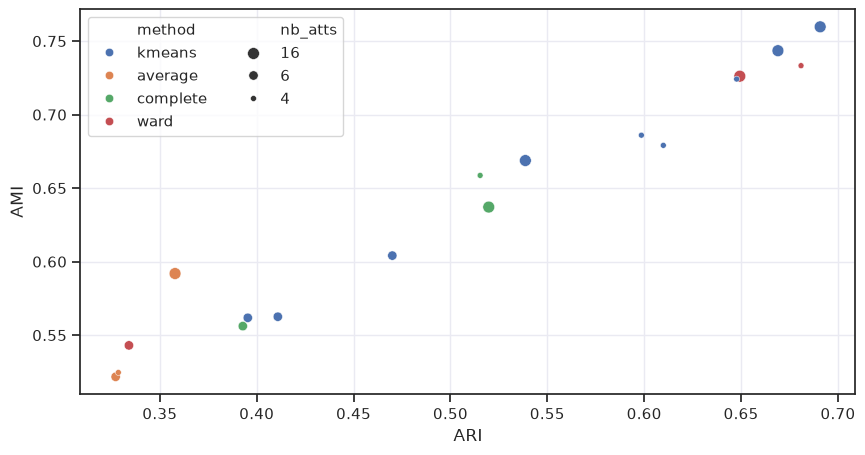

In [60]:
ax = seaborn.scatterplot(cmp_dtf, x="ARI", y="AMI", hue="method", size="nb_atts");
ax.legend(loc="upper left", ncols=2);

16. <a id="input_16"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the scores obtained for the different clusterings shown in the table and scatter plot above, and to explain what they mean in terms of the quality of the clusters and how well the clusterings match the reference.
Are the ARI and AMI scores consistent?
Are some clustering methods consistently achieving a better agreement with the reference?
</span>

✏️
...

To examine how the cluster assignments differ from the reference, we use our `plot_clustering_comparison` function to visually compare the best and worst matching clusterings in terms of AMI with the reference.

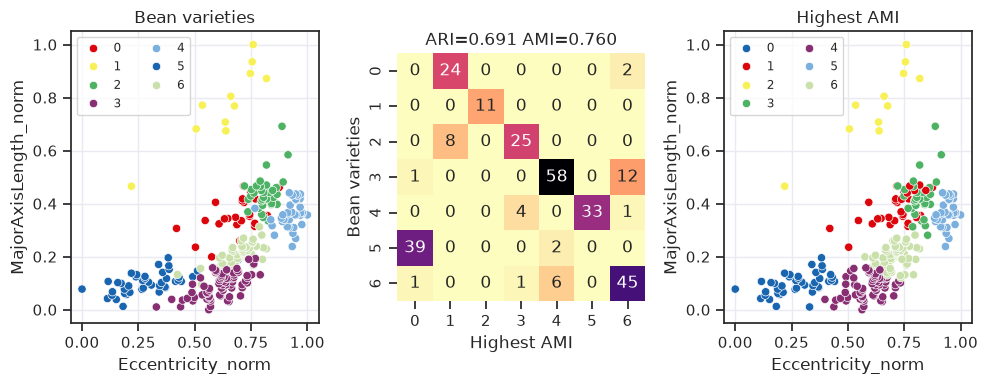

In [61]:
name_highest_ami = cmp_dtf.sort_values(by=["AMI"], ascending=False).iloc[0]["name"]
var_palette, km16_palette = plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "Bean varieties", "clusters_bean_varieties", "Highest AMI", name_highest_ami,
                colors=db_groupcolors, color_match="lhs", fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"})

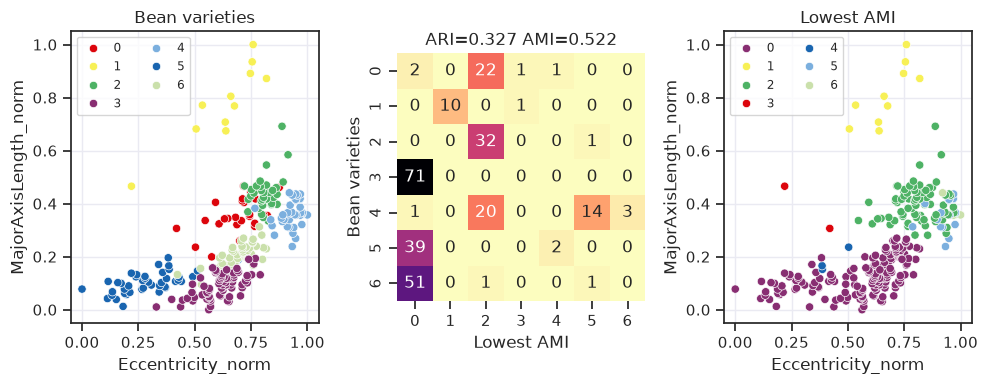

In [62]:
name_lowest_ami = cmp_dtf.sort_values(by=["AMI"], ascending=True).iloc[0]["name"]
var_palette, km16_palette = plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "Bean varieties", "clusters_bean_varieties", "Lowest AMI", name_lowest_ami,
                colors=db_groupcolors, color_match="lhs", fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"})

17. <a id="input_17"></a><span style="background-color:#FEDA8B;">
Which are the clusterings best and worst matching the reference?
Write a few sentences to describe your observations comparing those cluster assignments to the reference.
</span>

Finally, we focus on the results of agglomerative clustering with Ward linkage. We look in more details at the cluster assignments obtained when using different sets of attributes for clustering, from using just four selected attributes, to using all sixteen attributes, through using an intermediate set of six attributes.

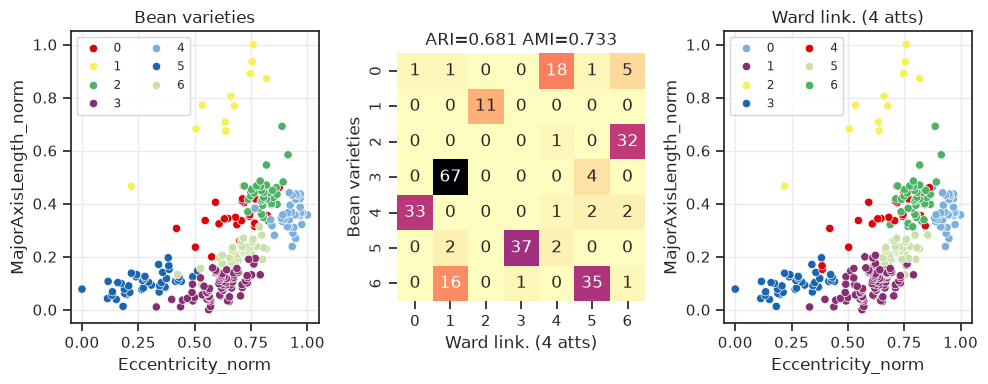

In [63]:
_, ward4_palette = plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "Bean varieties", "clusters_bean_varieties", "Ward link. (4 atts)", "clusters_4an_ward7",
                colors=db_groupcolors, color_match="lhs", lhs_palette=var_palette, fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"})

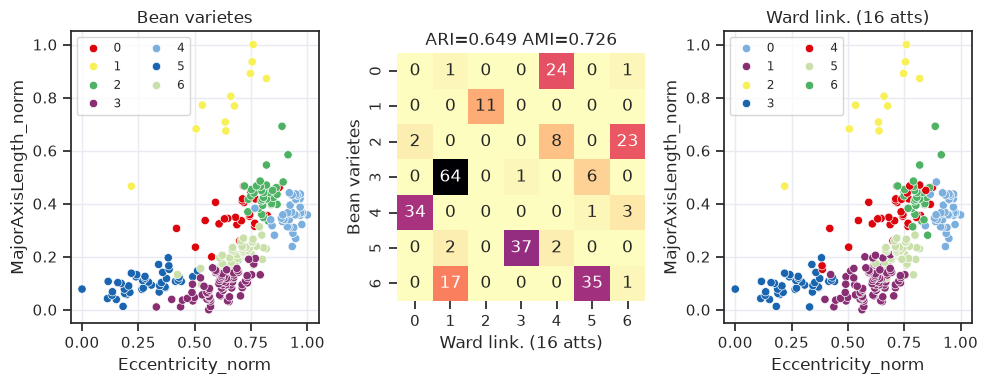

In [64]:
_, ward16_palette = plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "Bean varietes", "clusters_bean_varieties", "Ward link. (16 atts)", "clusters_16an_ward7",
                colors=db_groupcolors, color_match="lhs", lhs_palette=var_palette, fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"})

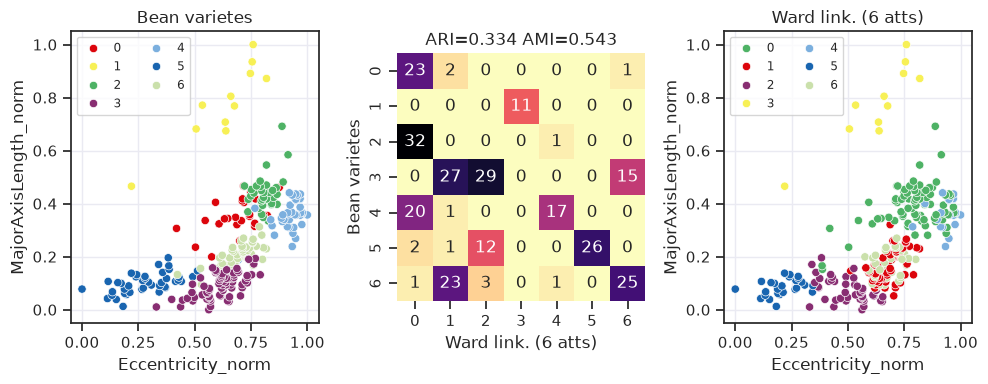

In [65]:
_, ward6_palette = plot_clustering_comparison(db_dtf, db_9attpairs_norm[4],
                "Bean varietes", "clusters_bean_varieties", "Ward link. (6 atts)", "clusters_6an_ward7",
                colors=db_groupcolors, color_match="lhs", lhs_palette=var_palette, fig_height=4,
                args_legend={"loc": "upper left", "ncols": 2, "fontsize": "x-small"})

We define a function to draw scatter plots of several clusterings next to each other, to be able to compare them. Each column in the grid shows one clustering from the list `color_columns`, with all scatter plots on a row using the same pair of attributes as coordinates, from the list `coordinates_columns`.

In [66]:
def scatter_compare(dtf, coordinates_columns, color_columns, colors=None, fig_height=None, args_legend=None):
    f, axes = plt.subplots(len(coordinates_columns), len(color_columns))
    for cj, (title, color_column, palette) in enumerate(color_columns):
        if palette is None:
            palette = dict([(-1, "#888888")]+
                        [(v, colors[i%len(colors)]) for (i, v) in enumerate([v for v in pandas.unique(dtf[color_column]) if v != -1])])
        for ci, (cx, cy) in enumerate(coordinates_columns):
            seaborn.scatterplot(dtf, x=cx, y=cy,
                        hue=color_column, palette=palette,
                        ax=axes[ci, cj], legend=(args_legend is None) or (ci in args_legend))
            if args_legend is not None and args_legend.get(ci) is not None:
                axes[ci, cj].legend(**args_legend[ci])
            if ci == 0:
                axes[ci, cj].set_title(title)
            if cj != 0:
                axes[ci, cj].set_ylabel("")
    if fig_height is not None:
        f.set_figheight(fig_height)
    f.tight_layout()

We use this function to visualize the reference alongside the clusterings obtained with Ward linkage on the different sets of attributes. We use four pairs of attributes as coordinates. Attributes from the first two pairs, `MajorAxisLength_norm`, `MinorAxisLength_norm`, `Eccentricity_norm` and `roundness_norm`, are included in all three subsets used for clustering. Attributes from the third pair, `Extent_norm` and `ShapeFactor2_norm`, do not belong to the smallest set, but are included in the other two, whereas attributes from the last pair, `Solidity_norm` and `ShapeFactor4_norm`, are only included in the largest set of attributes used for clustering, that which consists of all sixteen normalized attributes.

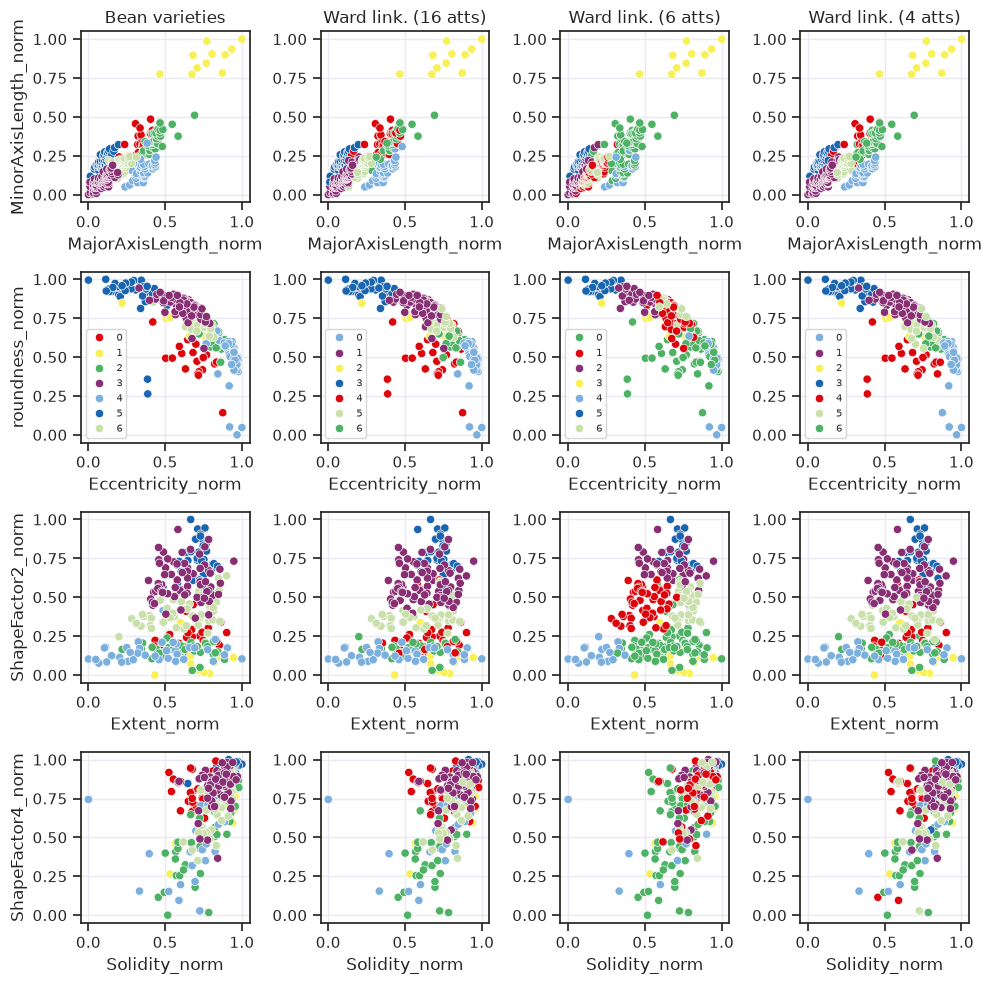

In [67]:
to_compare = [("Bean varieties", "clusters_bean_varieties", var_palette),
              ("Ward link. (16 atts)", "clusters_16an_ward7", ward16_palette),
              ("Ward link. (6 atts)", "clusters_6an_ward7", ward6_palette),
              ("Ward link. (4 atts)", "clusters_4an_ward7", ward4_palette)]
db_4attpairs_norm = [
    ("MajorAxisLength_norm", "MinorAxisLength_norm"),
    ("Eccentricity_norm", "roundness_norm"),
    ("Extent_norm", "ShapeFactor2_norm"),
    ("Solidity_norm","ShapeFactor4_norm"),
]
scatter_compare(db_dtf, db_4attpairs_norm, to_compare, db_groupcolors,
             fig_height=10, args_legend={1: {"loc": "lower left",  "fontsize": "xx-small"}})

18. <a id="input_18"></a><span style="background-color:#FEDA8B;">
You may add a few sentences to discuss the comparison between clusterings obtained with different sets of attributes.
</span>

✏️
...

## Conclusion

19. <a id="input_"></a><span style="background-color:#FEDA8B;">
Write a few sentences of conclusion, summarizing what you have learned from the notebook about the dataset, the clustering methods, the evaluation and comparison of the obtained cluster assignments, and the analysis pipeline.
</span>

✏️
...